In [308]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from statsmodels.tsa.seasonal import seasonal_decompose

In [341]:
data_path = os.path.abspath('c:\\Users\\Administrator\\Documents\\GitHub\\PrinciplesOfDataScience_Group2\\data\\time_series_data.csv') 
df = pd.read_csv(data_path)
# df = pd.read_csv('c:\\Users\\Administrator\\Documents\\GitHub\\PrinciplesOfDataScience_Group2\\data\\time_series_data.csv')
df.head(20)

,t,ProductP1,ProductP2,ProductP3,ProductP4,ProductP5,price,temperature
0,1,197,66,266,113,2,1,18
1,2,153,44,264,74,1,2,21
2,3,128,55,317,116,0,1,19
3,4,133,57,390,70,0,2,17
4,5,120,47,440,141,1,1,18
5,6,154,42,436,97,1,1,19
6,7,163,55,493,69,1,1,21
7,8,155,45,203,157,0,1,23
8,9,157,59,308,37,0,2,25
9,10,151,64,388,65,0,2,25


In [342]:
df.tail()

,t,ProductP1,ProductP2,ProductP3,ProductP4,ProductP5,price,temperature
95,96,174,226,975,94,0,1,2
96,97,158,201,1141,91,0,2,3
97,98,145,217,881,46,4,1,3
98,99,161,249,741,70,0,1,7
99,100,160,331,854,75,0,1,5


In [343]:
df.describe()

,t,ProductP1,ProductP2,ProductP3,ProductP4,ProductP5,price,temperature
count,100.000000,100.000000,100.000000,100.0000,100.000000,100.000000,100.000000,100.000000
mean,50.500000,148.370000,153.440000,631.5800,80.120000,0.550000,1.470000,13.020000
std,29.011492,18.061989,68.164288,202.8871,36.780891,1.225775,0.501614,5.915192
min,1.000000,107.000000,42.000000,203.0000,11.000000,0.000000,1.000000,2.000000
25%,25.750000,134.000000,95.500000,491.7500,55.750000,0.000000,1.000000,9.000000
50%,50.500000,151.000000,155.500000,611.0000,70.000000,0.000000,1.000000,13.000000
75%,75.250000,160.000000,200.250000,770.5000,100.250000,0.000000,2.000000,17.000000
max,100.000000,197.000000,331.000000,1141.0000,194.000000,5.000000,2.000000,26.000000


In [344]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   t            100 non-null    int64
 1   ProductP1    100 non-null    int64
 2   ProductP2    100 non-null    int64
 3   ProductP3    100 non-null    int64
 4   ProductP4    100 non-null    int64
 5   ProductP5    100 non-null    int64
 6   price        100 non-null    int64
 7   temperature  100 non-null    int64
dtypes: int64(8)
memory usage: 6.4 KB


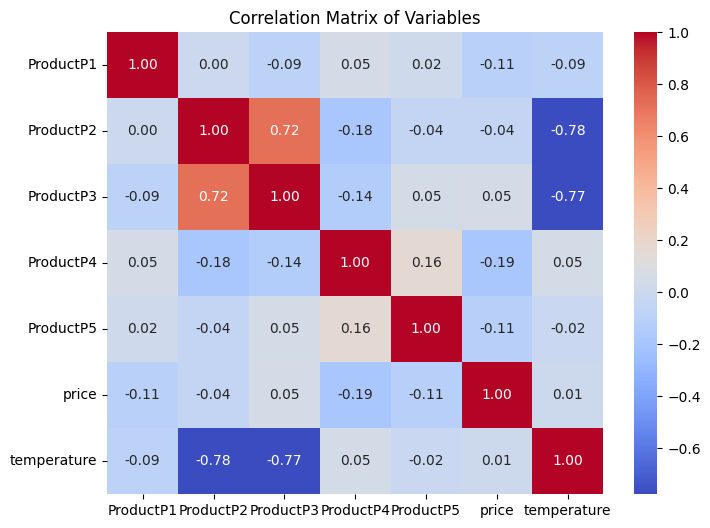

In [345]:
# Compute the correlation matrix
corr_matrix = df.drop(columns=["t"]).corr()

# correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Variables")
plt.show()

In [314]:
# Select only product columns for clustering
product_columns = ["ProductP1", "ProductP2", "ProductP3", "ProductP4", "ProductP5"]
X = df[product_columns]

In [315]:
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [316]:
# Determine the optimal number of clusters using the Elbow Method
inertia = []
K = range(1, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

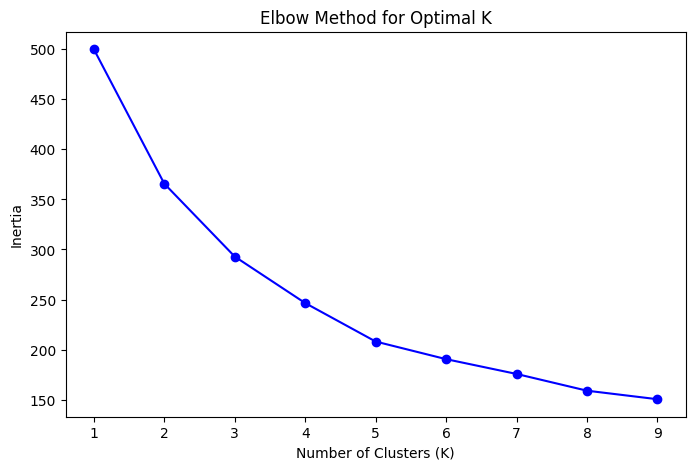

In [317]:
# Plot the Elbow curve
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, 'bo-')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()

In [318]:
# Apply PCA with all components
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)

# Get explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

# Print results
for i, (var, cum_var) in enumerate(zip(explained_variance_ratio, cumulative_variance), 1):
    print(f"PC{i}: {var:.4f} (Cumulative: {cum_var:.4f})")

PC1: 0.3582 (Cumulative: 0.3582)
PC2: 0.2276 (Cumulative: 0.5857)
PC3: 0.1989 (Cumulative: 0.7847)
PC4: 0.1609 (Cumulative: 0.9456)
PC5: 0.0544 (Cumulative: 1.0000)


In [325]:
# Choose the optimal number of clusters (based on the Elbow method)
optimal_k = 3

# Apply K-Means clustering
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
X["Cluster"] = kmeans.fit_predict(X_scaled)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_27064\3956001042.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Cluster"] = kmeans.fit_predict(X_scaled)


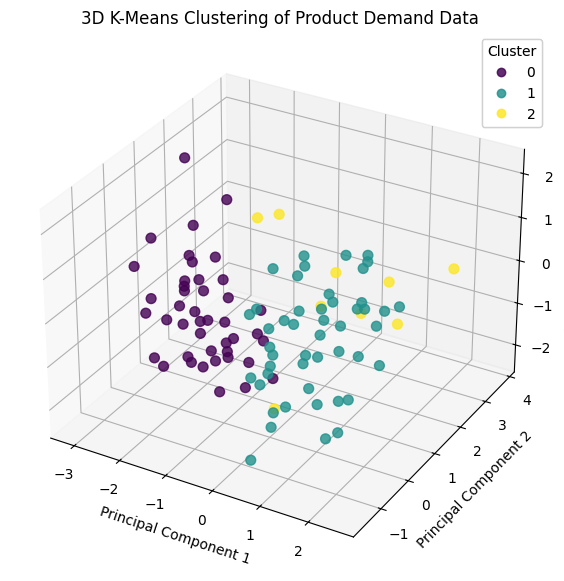

In [320]:
# Apply PCA with n_components=3
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Create a 3D scatter plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot with cluster colors
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], 
                      c=df["Cluster"], cmap="viridis", s=50, alpha=0.8)

# Labels and title
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")
ax.set_title("3D K-Means Clustering of Product Demand Data")

# Add a legend
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)

# Show the plot
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_27064\528775219.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Cluster"] = X["Cluster"].astype(str)  # Convert to string for better color distinction


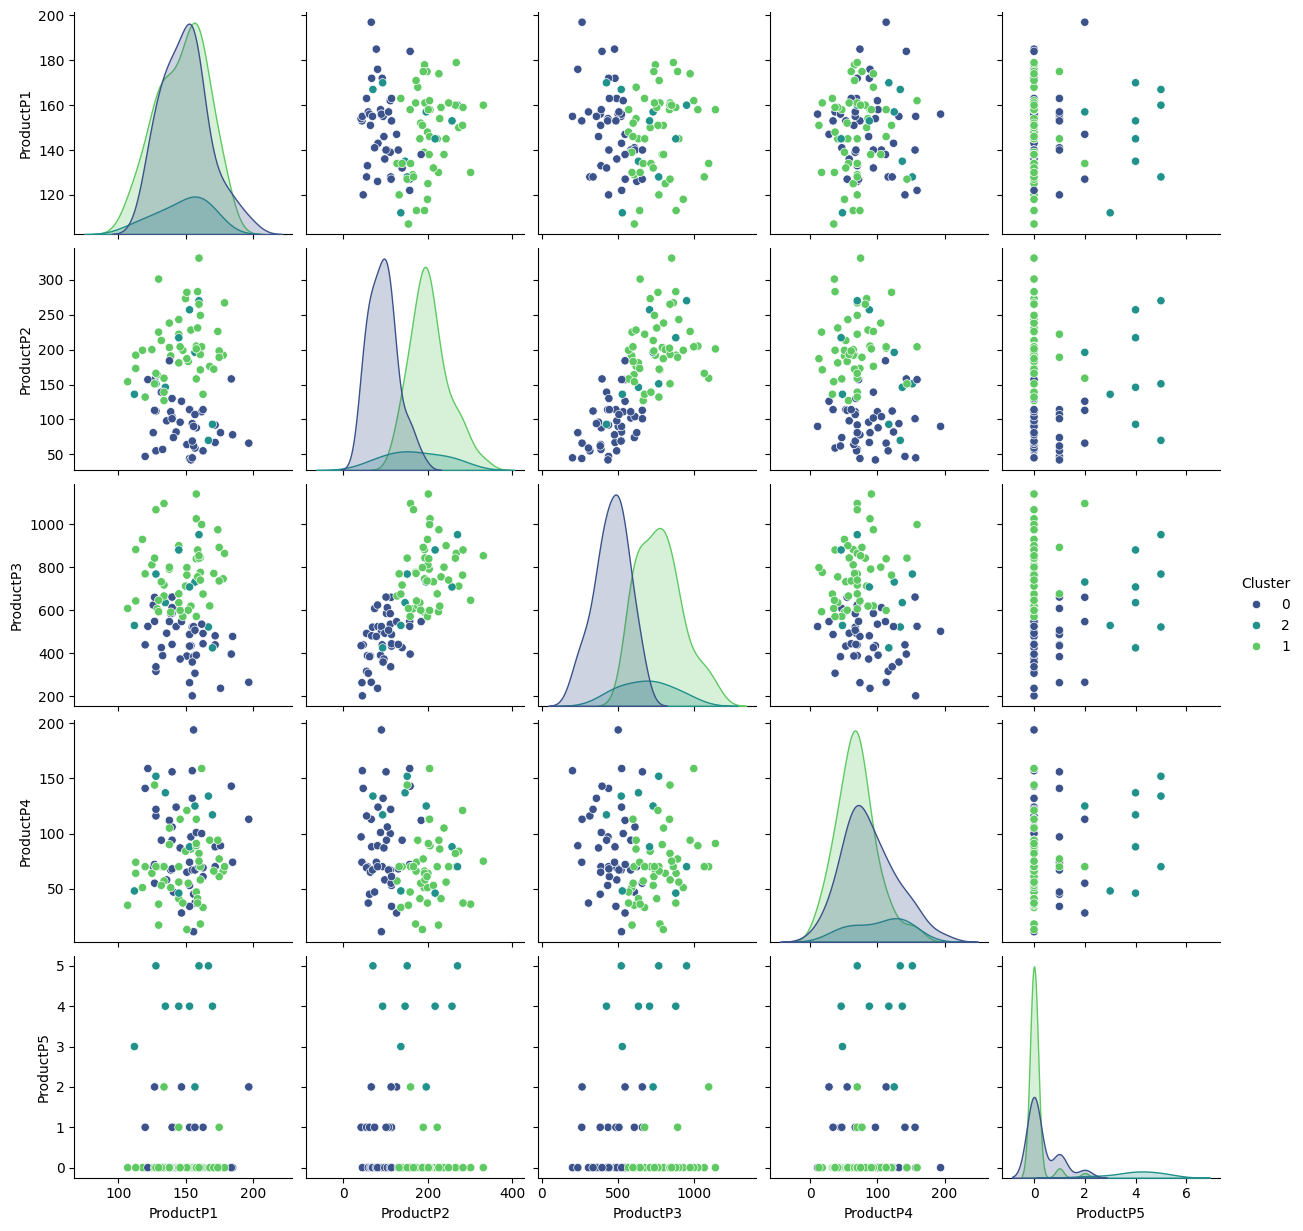

In [326]:
# Pair plot
X["Cluster"] = X["Cluster"].astype(str)  # Convert to string for better color distinction
sns.pairplot(X, hue="Cluster", palette="viridis", diag_kind="kde")

In [295]:
# Separate weekly and daily products
weekly_products = ["ProductP1", "ProductP2", "ProductP5"]
daily_products = ["ProductP3", "ProductP4"]

# Extract weekly and daily data
weekly_data = df[["t"] + weekly_products + ["price", "temperature"]]
daily_data = df[["t"] + daily_products + ["price", "temperature"]]

In [296]:
weekly_data.describe()

,t,ProductP1,ProductP2,ProductP5,price,temperature
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,50.500000,148.370000,153.440000,0.550000,1.470000,13.020000
std,29.011492,18.061989,68.164288,1.225775,0.501614,5.915192
min,1.000000,107.000000,42.000000,0.000000,1.000000,2.000000
25%,25.750000,134.000000,95.500000,0.000000,1.000000,9.000000
50%,50.500000,151.000000,155.500000,0.000000,1.000000,13.000000
75%,75.250000,160.000000,200.250000,0.000000,2.000000,17.000000
max,100.000000,197.000000,331.000000,5.000000,2.000000,26.000000


In [327]:
# Standardize the data
wd_scaled = scaler.fit_transform(weekly_data)

In [331]:
# Choose the optimal number of clusters (based on the Elbow method)
optimal_k = 3

# Apply K-Means clustering
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
weekly_data["Cluster"] = kmeans.fit_predict(wd_scaled)

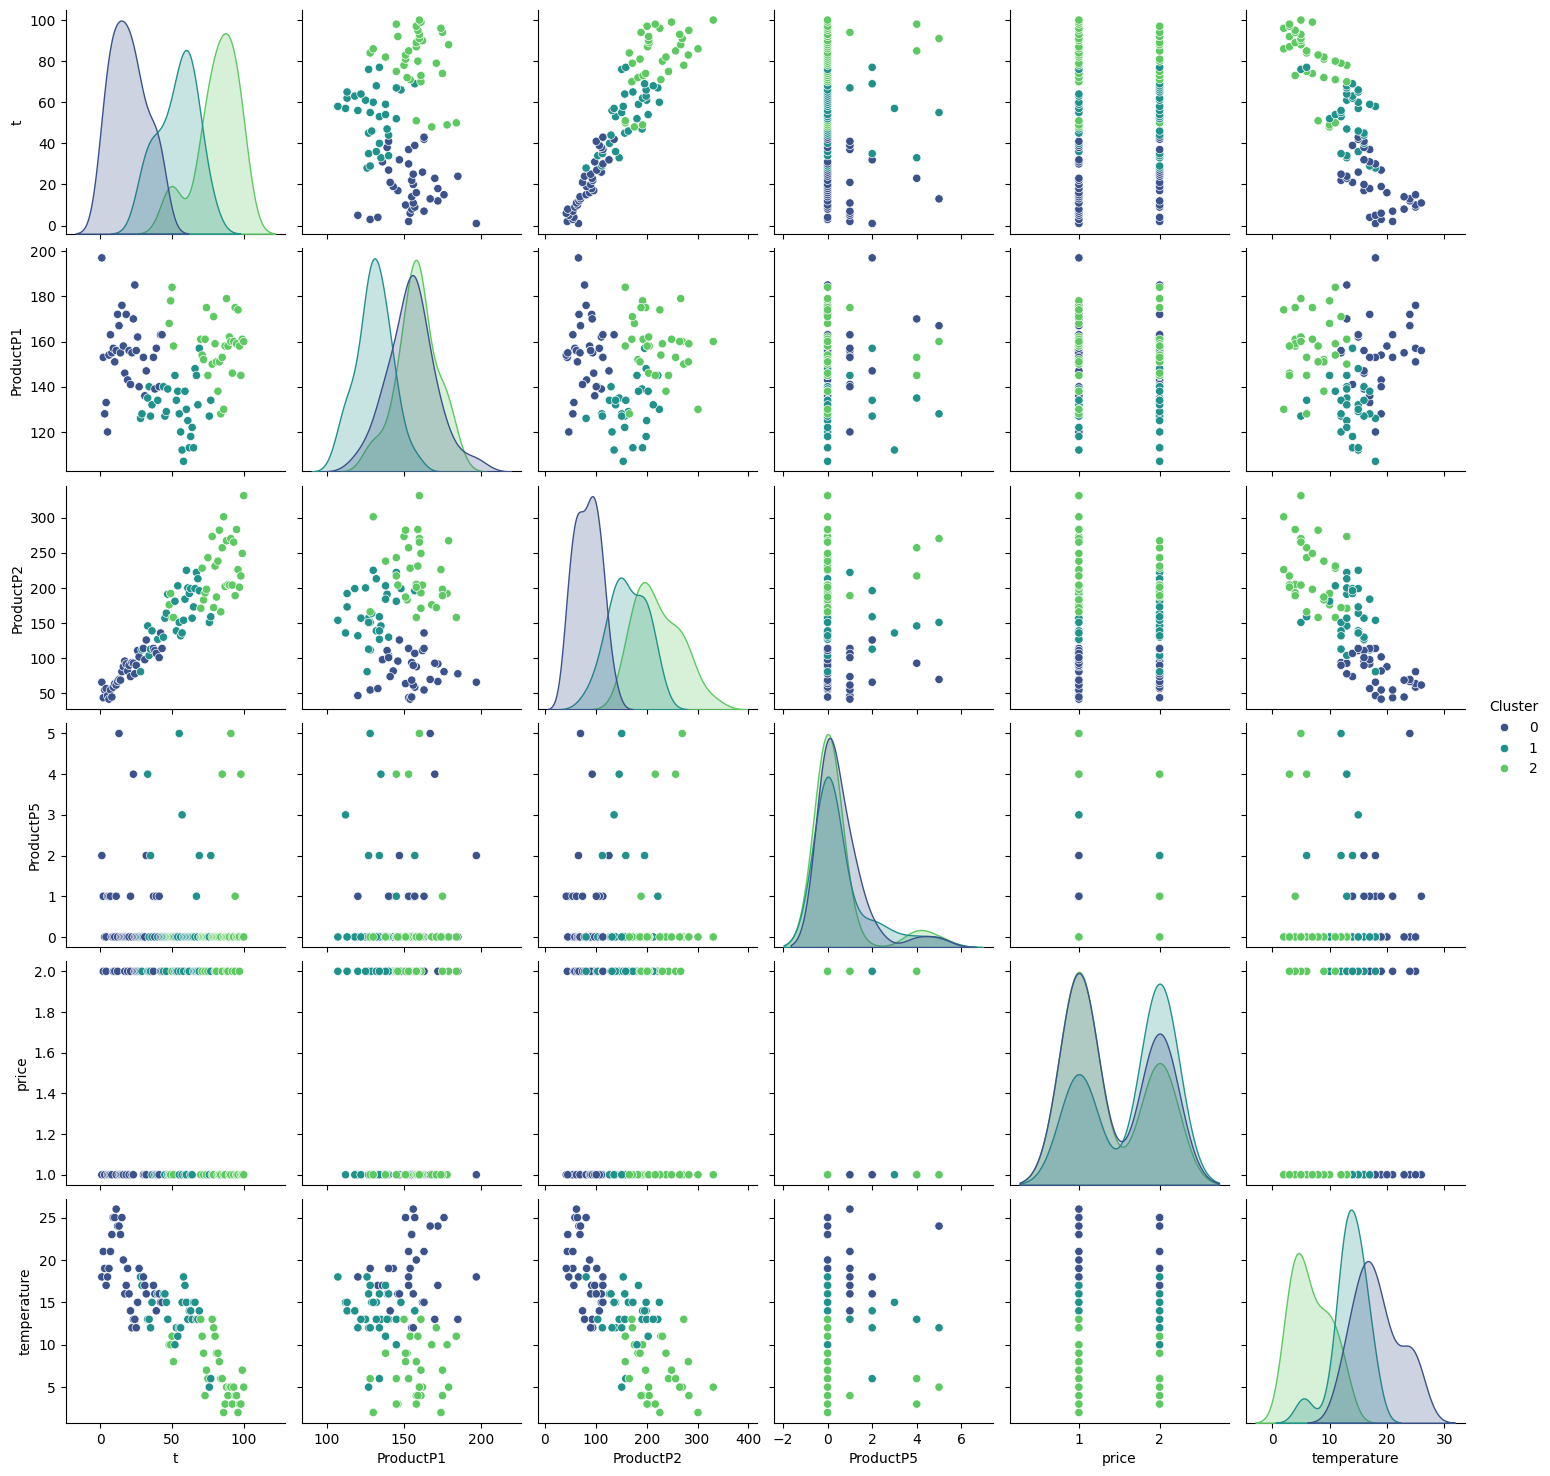

In [332]:
# Pair plot
weekly_data["Cluster"] = weekly_data["Cluster"].astype(str)
sns.pairplot(weekly_data, hue="Cluster", palette="viridis", diag_kind="kde")

In [297]:
daily_data.describe()

,t,ProductP3,ProductP4,price,temperature
count,100.000000,100.0000,100.000000,100.000000,100.000000
mean,50.500000,631.5800,80.120000,1.470000,13.020000
std,29.011492,202.8871,36.780891,0.501614,5.915192
min,1.000000,203.0000,11.000000,1.000000,2.000000
25%,25.750000,491.7500,55.750000,1.000000,9.000000
50%,50.500000,611.0000,70.000000,1.000000,13.000000
75%,75.250000,770.5000,100.250000,2.000000,17.000000
max,100.000000,1141.0000,194.000000,2.000000,26.000000


In [333]:
# Standardize the data
dd_scaled = scaler.fit_transform(daily_data)

In [334]:
# Choose the optimal number of clusters (based on the Elbow method)
optimal_k = 3

# Apply K-Means clustering
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
daily_data["Cluster"] = kmeans.fit_predict(dd_scaled)

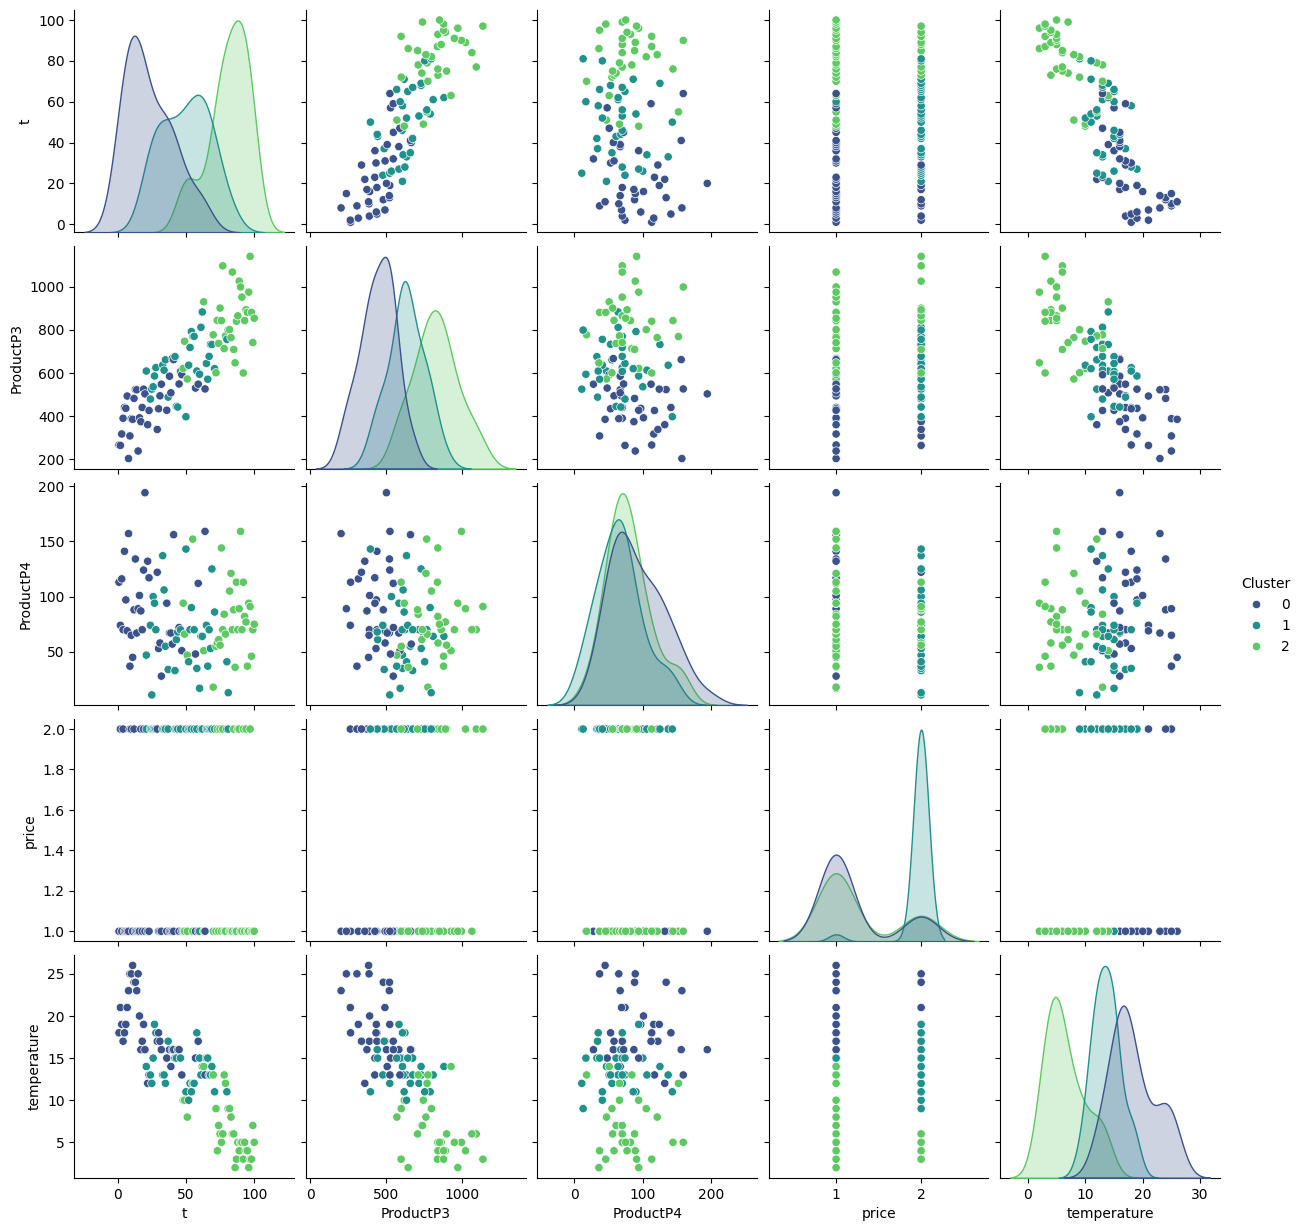

In [335]:
# Pair plot
daily_data["Cluster"] = daily_data["Cluster"].astype(str)
sns.pairplot(daily_data, hue="Cluster", palette="viridis", diag_kind="kde")

In [298]:
import matplotlib.pyplot as plt

# Define time ranges for each product
weekly_end_dates = {"ProductP1": 70, "ProductP2": 70, "ProductP5": 70}  # Approximate weekly indices
daily_end_dates = {"ProductP3": 84, "ProductP4": 84}  # Daily indices

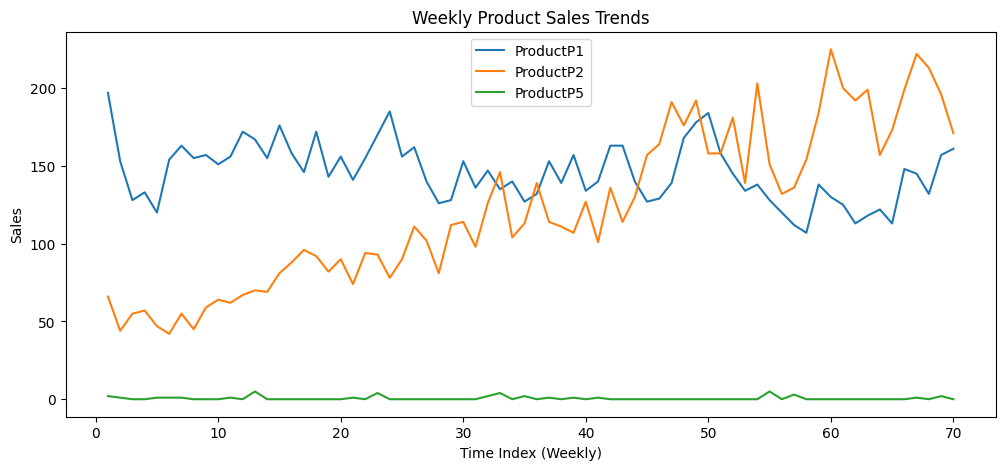

In [299]:
# Plot weekly data
plt.figure(figsize=(12, 5))
for product, end_date in weekly_end_dates.items():
    plt.plot(df["t"][:end_date], df[product][:end_date], label=product)
plt.legend()
plt.title("Weekly Product Sales Trends")
plt.xlabel("Time Index (Weekly)")
plt.ylabel("Sales")
plt.show()

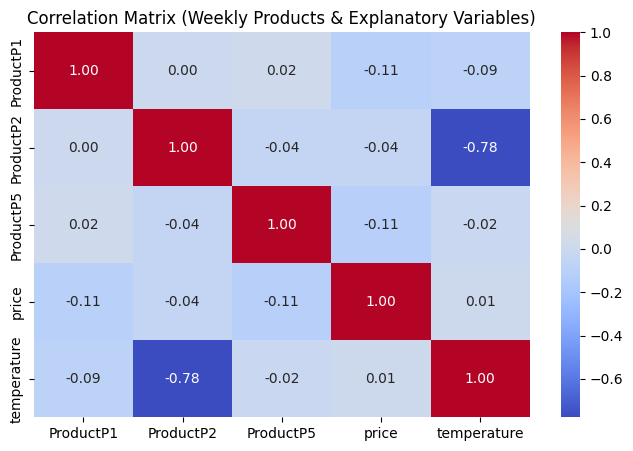

In [300]:
import seaborn as sns

# Compute correlation matrix for daily products and explanatory variables
corr_matrix = weekly_data.drop(columns=["t"]).corr()

# Plot correlation heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix (Weekly Products & Explanatory Variables)")
plt.show()

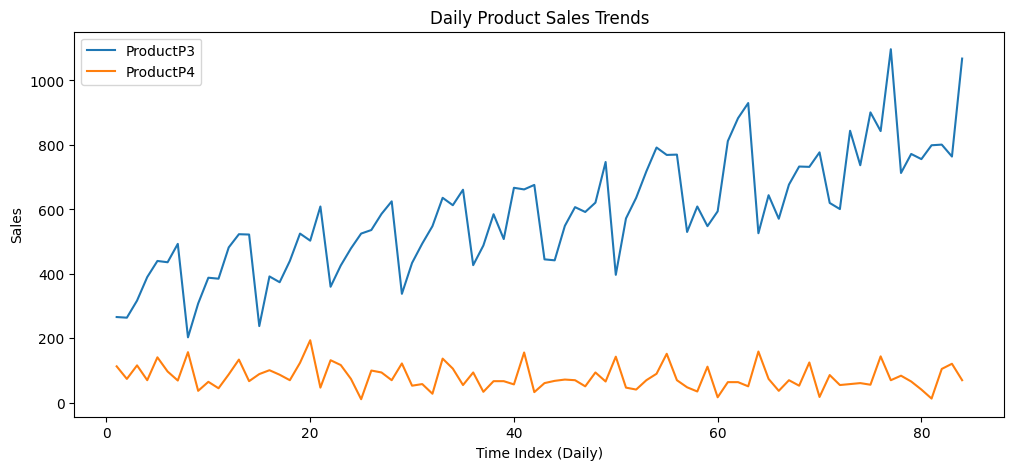

In [31]:
# Plot daily data
plt.figure(figsize=(12, 5))
for product, end_date in daily_end_dates.items():
    plt.plot(df["t"][:end_date], df[product][:end_date], label=product)
plt.legend()
plt.title("Daily Product Sales Trends")
plt.xlabel("Time Index (Daily)")
plt.ylabel("Sales")
plt.show()

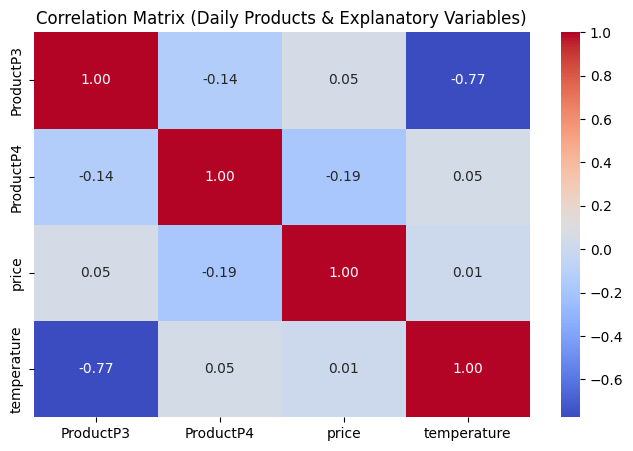

In [40]:
import seaborn as sns

# Compute correlation matrix for daily products and explanatory variables
corr_matrix = daily_data.drop(columns=["t"]).corr()

# Plot correlation heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix (Daily Products & Explanatory Variables)")
plt.show()

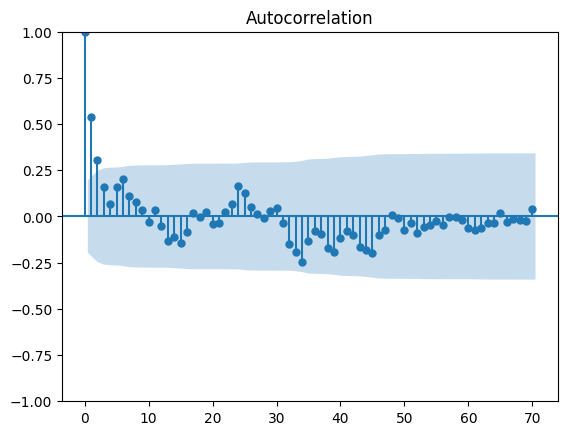

In [50]:
#Autocorelation weekly
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plot_acf(weekly_data["ProductP1"], lags=70)  # Adjust lags based on your data length
plt.show()

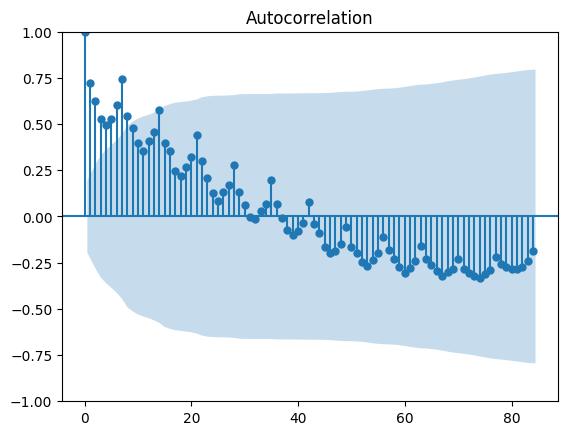

In [48]:
#Autocorelation daily
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plot_acf(daily_data["ProductP3"], lags=84)  # Adjust lags based on your data length
plt.show()

In [75]:
from statsmodels.tsa.stattools import adfuller

# Function to check stationarity
def check_stationarity(series):
    result = adfuller(series)
    return {"Test Statistic": result[0], "p-value": result[1], "Stationary": result[1] < 0.05}

# Apply ADF test to all columns
stationarity_results = {col: check_stationarity(df[col]) for col in df.columns}
pd.DataFrame(stationarity_results).T

,Test Statistic,p-value,Stationary
t,2.348113,0.998984,False
ProductP1,-5.675633,0.000001,True
ProductP2,-0.861551,0.800371,False
ProductP3,-0.234873,0.934235,False
ProductP4,-11.455483,0.0,True
ProductP5,-11.152511,0.0,True
price,-2.616794,0.089576,False
temperature,-1.547096,0.510098,False


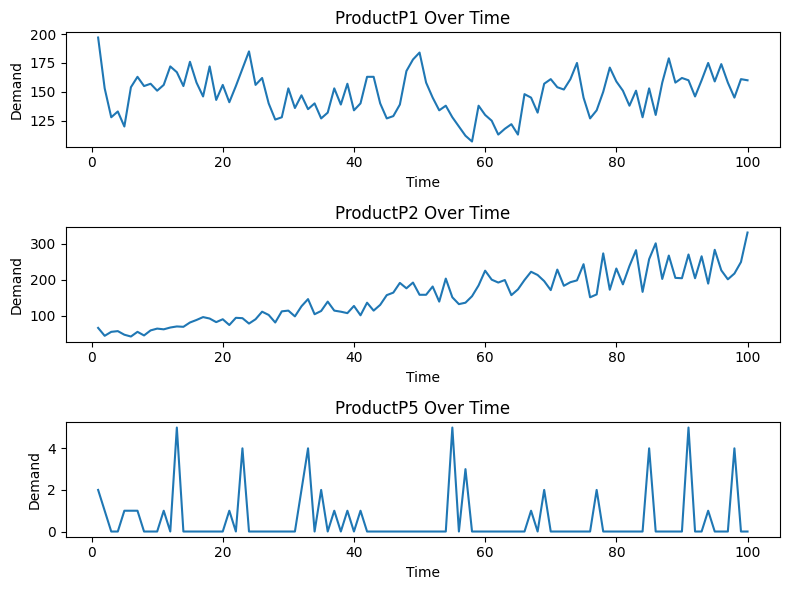

In [73]:
plt.figure(figsize=(8, 6))
cols = ["ProductP1","ProductP2","ProductP5"]

for idx, i in enumerate(cols):
    plt.subplot(3, 1, idx+1)
    plt.plot(weekly_data["t"], df[i], label=i)
    plt.xlabel("Time")
    plt.ylabel("Demand")
    plt.title(f"{i} Over Time")
plt.tight_layout()
plt.show()

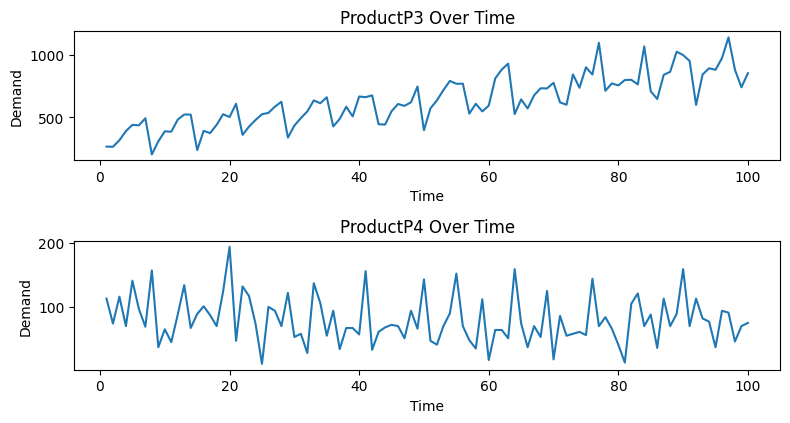

In [74]:
plt.figure(figsize=(8, 6))
cols = ["ProductP3","ProductP4"]

for idx, i in enumerate(cols):
    plt.subplot(3, 1, idx+1)
    plt.plot(daily_data["t"], df[i], label=i)
    plt.xlabel("Time")
    plt.ylabel("Demand")
    plt.title(f"{i} Over Time")
plt.tight_layout()
plt.show()

In [88]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Perform seasonal decomposition for ProductP1 (weekly) and ProductP4 (daily with explanatory variables)
weekly_series = df.loc[:weekly_end_dates["ProductP2"], "ProductP2"]
daily_series = df.loc[:daily_end_dates["ProductP3"], "ProductP3"]

# Decompose weekly product
weekly_decomp = seasonal_decompose(weekly_series, period=4, model="multiplicative")
daily_decomp = seasonal_decompose(daily_series, period=7, model="multiplicative")

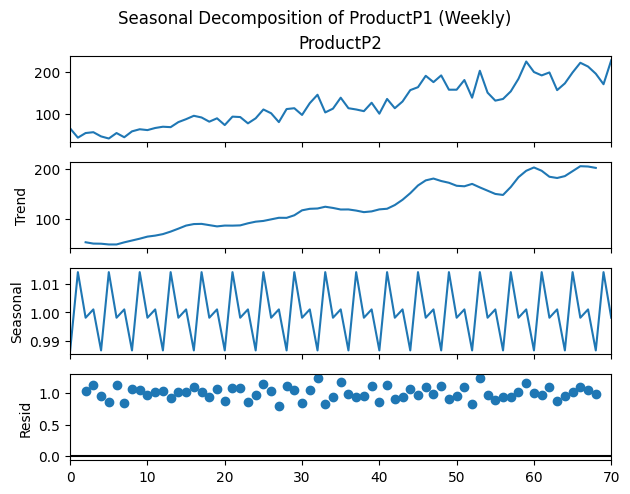

In [89]:
# Plot decompositions
weekly_decomp.plot()
plt.suptitle("Seasonal Decomposition of ProductP1 (Weekly)", y=1.02)
plt.show()

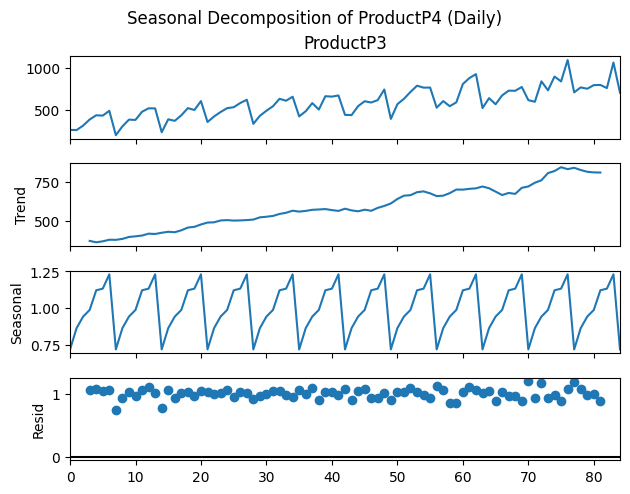

In [84]:
daily_decomp.plot()
plt.suptitle("Seasonal Decomposition of ProductP4 (Daily)", y=1.02)
plt.show()

In [349]:
from statsmodels.tsa.stattools import grangercausalitytests

# Run the Granger causality test
max_lag = 5  # Adjust as needed
gc_test = grangercausalitytests(df[['ProductP3', 'temperature']], maxlag=max_lag, verbose=False)

# Extract p-values for each lag
p_values = {lag: round(gc_test[lag][0]['ssr_chi2test'][1], 4) for lag in range(1, max_lag + 1)}

# Display p-values
print("Granger Causality p-values:", p_values)

Granger Causality p-values: {1: 0.0, 2: 0.0, 3: 0.0001, 4: 0.001, 5: 0.0128}


C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


In [353]:
from statsmodels.tsa.stattools import coint

# Compute correlation between ProductP3 and ProductP4
correlation_p3_p4 = df["ProductP3"].corr(df["ProductP4"])
print(f"Correlation between P3 and P4: {correlation_p3_p4:.2f}")

# Perform Engle-Granger cointegration test
coint_test_stat, p_value, _ = coint(df["ProductP3"], df["ProductP4"])
print(f"Cointegration test p-value: {p_value:.4f}")

# Interpretation
if p_value < 0.05:
    print("P3 and P4 are likely cointegrated (suggests using VECM).")
else:
    print("No strong cointegration detected (VAR might be a better choice).")

Correlation between P3 and P4: -0.14
Cointegration test p-value: 0.9594
No strong cointegration detected (VAR might be a better choice).


In [356]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

# Select only the relevant columns
data = df[["ProductP3", "ProductP4"]]

# Perform Johansen test
johansen_test = coint_johansen(data, det_order=0, k_ar_diff=1)

# Trace statistic and critical values
trace_stat = johansen_test.lr1
critical_values = johansen_test.cvt

# Display results
for i in range(len(trace_stat)):
    print(f"Rank {i}: Trace Statistic = {trace_stat[i]:.4f}, Critical Values = {critical_values[i]}")
    
    if trace_stat[i] > critical_values[i][1]:  # Compare with 5% critical value
        print("=> Evidence of cointegration at 5% significance level.")
    else:
        print("=> No strong evidence of cointegration.")

Rank 0: Trace Statistic = 66.5734, Critical Values = [13.4294 15.4943 19.9349]
=> Evidence of cointegration at 5% significance level.
Rank 1: Trace Statistic = 9.7024, Critical Values = [2.7055 3.8415 6.6349]
=> Evidence of cointegration at 5% significance level.


In [357]:
from statsmodels.tsa.stattools import coint

# Compute correlation between ProductP3 and ProductP4
correlation_p3_p4 = df["ProductP2"].corr(df["ProductP3"])
print(f"Correlation between P3 and P4: {correlation_p3_p4:.2f}")

# Perform Engle-Granger cointegration test
coint_test_stat, p_value, _ = coint(df["ProductP2"], df["ProductP3"])
print(f"Cointegration test p-value: {p_value:.4f}")

# Interpretation
if p_value < 0.05:
    print("P2 and P3 are likely cointegrated (suggests using VECM).")
else:
    print("No strong cointegration detected (VAR might be a better choice).")

Correlation between P3 and P4: 0.72
Cointegration test p-value: 0.6013
No strong cointegration detected (VAR might be a better choice).


In [120]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

# Load your sales demand data (ensure it's time-series indexed)
product1_sales = df['ProductP3']
product2_sales = df['ProductP4']

# Step 1: Check if both series are non-stationary
print("ADF Test for Product 1 Sales:", adfuller(product1_sales)[1])  # p-value
print("ADF Test for Product 2 Sales:", adfuller(product2_sales)[1])  # p-value

# Step 2: Run OLS regression
regression = sm.OLS(product1_sales, sm.add_constant(product2_sales)).fit()

# Step 3: Extract residuals
residuals = regression.resid

# Step 4: Test residuals for stationarity
adf_result = adfuller(residuals)
print("ADF Test for Residuals:", adf_result[1])  # p-value

if adf_result[1] < 0.05:
    print("The two product sales demands are cointegrated.")
else:
    print("No cointegration detected.")

ADF Test for Product 1 Sales: 0.9342351563563018
ADF Test for Product 2 Sales: 5.72054444868074e-21
ADF Test for Residuals: 0.9315229593091823
No cointegration detected.


### Model Development

### Product 1

In [139]:
import pandas as pd

# Load dataset
# file_path = "your_file_path.csv"  # Change this to your actual file path
# df = pd.read_csv(file_path)

# Rename columns for FBProphet
df_prophet = df.rename(columns={"t": "ds", "ProductP1": "y"})

# Convert 'ds' into a proper datetime format (assuming 't' represents sequential days)
df_prophet["ds"] = pd.date_range(start="2023-01-01", periods=len(df_prophet), freq="D")

# Keep only necessary columns
df_prophet = df_prophet[["ds", "y"]]

In [140]:
from prophet import Prophet

# Initialize Prophet model
model = Prophet()
# model.add_regressor("temp")  # Add temperature as an external regressor

# Fit the model
model.fit(df_prophet)

# Create future dataframe (next 30 days)
future = model.make_future_dataframe(periods=30)
# future["temp"] = df_prophet["temp"].mean()  # Assuming average temperature for future predictions

# Forecast
forecast = model.predict(future)

08:58:23 - cmdstanpy - INFO - Chain [1] start processing
08:58:23 - cmdstanpy - INFO - Chain [1] done processing


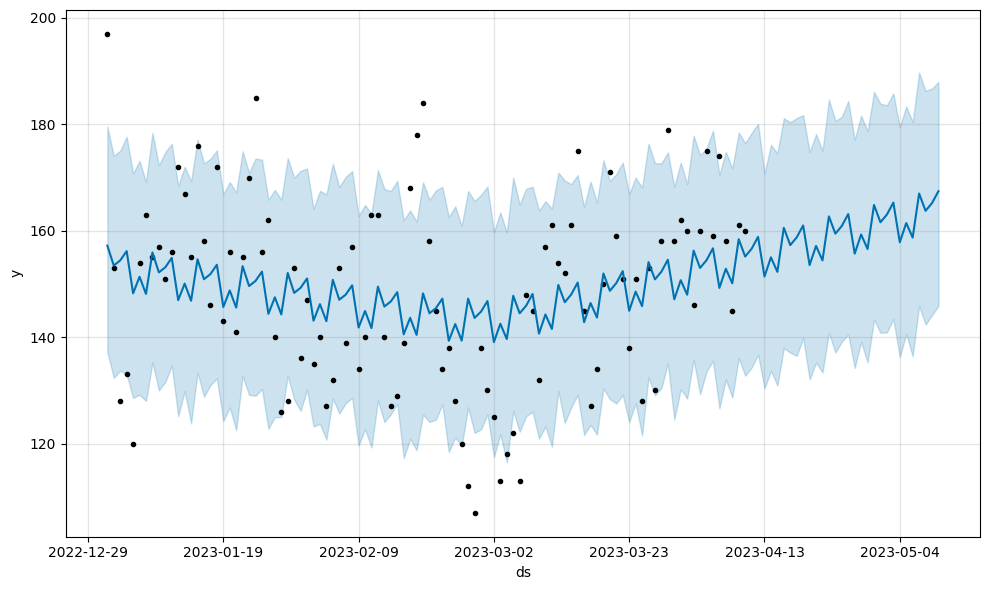

In [141]:
import matplotlib.pyplot as plt

# Plot forecast
fig = model.plot(forecast)
plt.show()

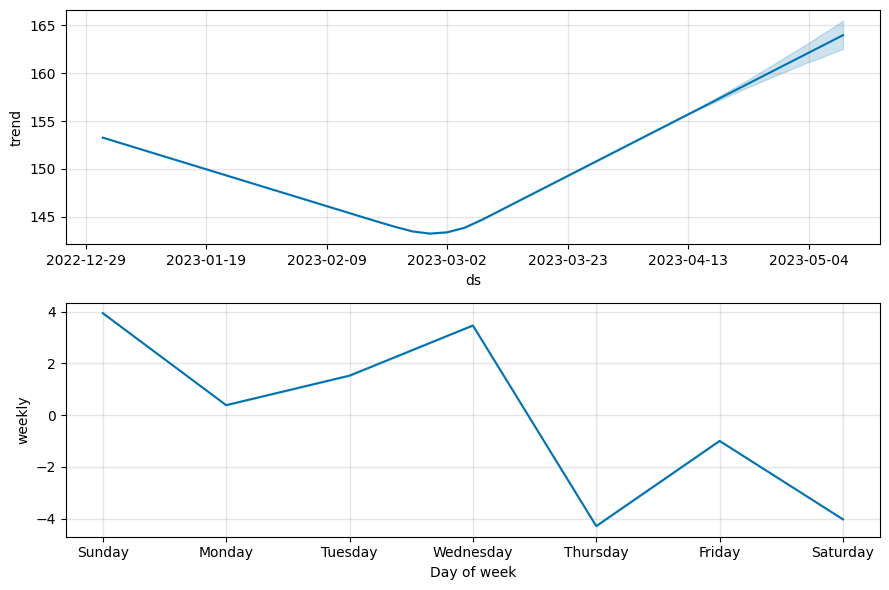

In [142]:
# Plot forecast components (trend, seasonality, effect of temp)
fig2 = model.plot_components(forecast)
plt.show()

In [180]:
from prophet import Prophet
from sklearn.model_selection import ParameterGrid
import numpy as np

# Define hyperparameter grid
param_grid = {
    "changepoint_prior_scale": [0.001, 0.01, 0.05, 0.1, 0.5],
    "seasonality_prior_scale": [0.1, 1.0, 10.0, 20.0],
    "seasonality_mode": ["additive", "multiplicative"]
}

# Create all combinations of parameters
grid = list(ParameterGrid(param_grid))

# Split dataset for cross-validation
split_point = int(len(df_prophet) * 0.8)  # 80% train, 20% test
train_df = df_prophet[:split_point]
test_df = df_prophet[split_point:]

best_model = None
best_mse = float("inf")
best_params = None

for params in grid:
    # Initialize and fit model
    model = Prophet(
        changepoint_prior_scale=params["changepoint_prior_scale"],
        seasonality_prior_scale=params["seasonality_prior_scale"],
        seasonality_mode=params["seasonality_mode"]
    )
    # model.add_regressor("temp")
    model.fit(train_df)
    
    # Make future dataframe
    future = model.make_future_dataframe(periods=len(test_df))
    # future["temp"] = test_df["temp"].values  # Use actual future temperature values

    # Predict
    forecast = model.predict(future)
    
    # Calculate error (Mean Squared Error)
    mse = np.mean((forecast["yhat"].iloc[-len(test_df):].values - test_df["y"].values) ** 2)
    
    # Save the best model
    if mse < best_mse:
        best_mse = mse
        best_model = model
        best_params = params

print("Best Parameters:", best_params)
print("Best MSE:", best_mse)

10:40:43 - cmdstanpy - INFO - Chain [1] start processing
10:40:43 - cmdstanpy - INFO - Chain [1] done processing
10:40:43 - cmdstanpy - INFO - Chain [1] start processing
10:40:44 - cmdstanpy - INFO - Chain [1] done processing
10:40:44 - cmdstanpy - INFO - Chain [1] start processing
10:40:45 - cmdstanpy - INFO - Chain [1] done processing
10:40:45 - cmdstanpy - INFO - Chain [1] start processing
10:40:45 - cmdstanpy - INFO - Chain [1] done processing
10:40:46 - cmdstanpy - INFO - Chain [1] start processing
10:40:46 - cmdstanpy - INFO - Chain [1] done processing
10:40:46 - cmdstanpy - INFO - Chain [1] start processing
10:40:46 - cmdstanpy - INFO - Chain [1] done processing
10:40:46 - cmdstanpy - INFO - Chain [1] start processing
10:40:47 - cmdstanpy - INFO - Chain [1] done processing
10:40:47 - cmdstanpy - INFO - Chain [1] start processing
10:40:47 - cmdstanpy - INFO - Chain [1] done processing
10:40:47 - cmdstanpy - INFO - Chain [1] start processing
10:40:47 - cmdstanpy - INFO - Chain [1]

Best Parameters: {'changepoint_prior_scale': 0.1, 'seasonality_mode': 'multiplicative', 'seasonality_prior_scale': 0.1}
Best MSE: 180.21789880655214


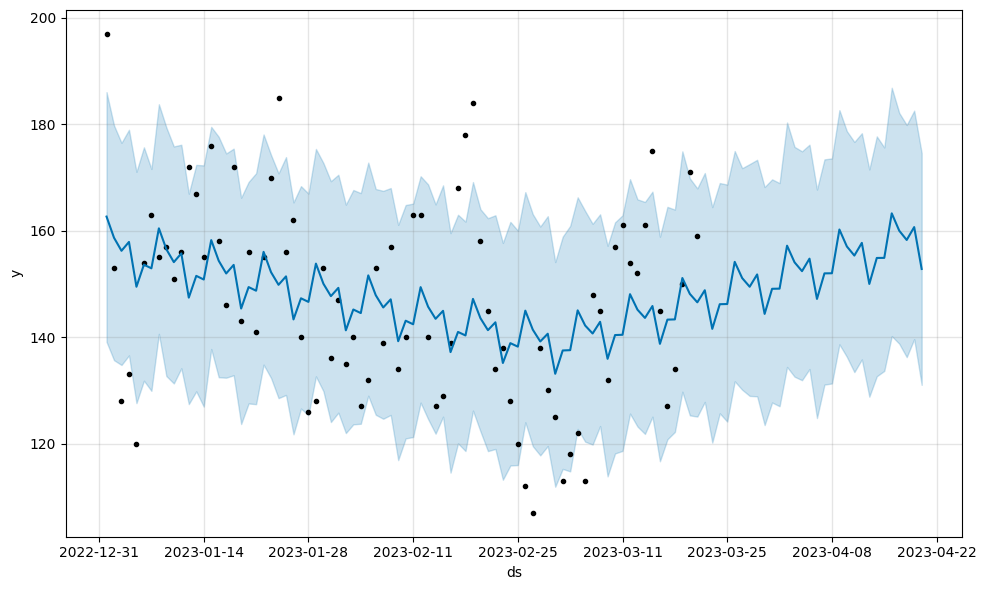

In [181]:
import matplotlib.pyplot as plt

# Predict using the best model
future = best_model.make_future_dataframe(periods=30)
# future["temp"] = df_prophet["temp"].mean()  # Assuming avg temperature

forecast = best_model.predict(future)

# Plot the forecast
best_model.plot(forecast)
plt.show()

In [184]:
from prophet.diagnostics import cross_validation, performance_metrics

# Adjust parameters for small dataset
df_cv = cross_validation(best_model, 
                         horizon="5 days",   # Reduce forecast window
                         period="3 days",    # Reduce step size
                         initial="60 days")  # Ensure training window fits data

# Evaluate performance
df_perf = performance_metrics(df_cv)
df_perf.head()

  0%|          | 0/5 [00:00<?, ?it/s]

10:41:19 - cmdstanpy - INFO - Chain [1] start processing
10:41:19 - cmdstanpy - INFO - Chain [1] done processing
10:41:19 - cmdstanpy - INFO - Chain [1] start processing
10:41:19 - cmdstanpy - INFO - Chain [1] done processing
10:41:19 - cmdstanpy - INFO - Chain [1] start processing
10:41:20 - cmdstanpy - INFO - Chain [1] done processing
10:41:20 - cmdstanpy - INFO - Chain [1] start processing
10:41:20 - cmdstanpy - INFO - Chain [1] done processing
10:41:20 - cmdstanpy - INFO - Chain [1] start processing
10:41:20 - cmdstanpy - INFO - Chain [1] done processing


,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,1 days,547.552468,23.399839,22.304890,0.152595,0.138850,0.159467,0.6
1,2 days,536.485900,23.162165,19.559777,0.133698,0.117306,0.139112,0.8
2,3 days,438.110937,20.931100,18.751142,0.123888,0.134231,0.134161,0.8
3,4 days,723.615361,26.900100,24.176897,0.152139,0.170733,0.167082,0.4
4,5 days,607.259011,24.642626,19.322261,0.119457,0.114262,0.131596,0.6


### Product 2

In [190]:
# Rename columns for FBProphet
df_prophet = df.rename(columns={"t": "ds", "ProductP2": "y", "temperature": "temp"})

# Convert 'ds' into a proper datetime format (assuming 't' represents sequential days)
df_prophet["ds"] = pd.date_range(start="2023-01-01", periods=len(df_prophet), freq="D")

# Keep only necessary columns
df_prophet = df_prophet[["ds", "y", "temp"]]

In [191]:
from prophet import Prophet

# Initialize Prophet model
model = Prophet()
model.add_regressor("temp")  # Add temperature as an external regressor

# Fit the model
model.fit(df_prophet)

# Create future dataframe (next 30 days)
future = model.make_future_dataframe(periods=30)
future["temp"] = df_prophet["temp"].mean()  # Assuming average temperature for future predictions

# Forecast
forecast = model.predict(future)

10:44:31 - cmdstanpy - INFO - Chain [1] start processing
10:44:31 - cmdstanpy - INFO - Chain [1] done processing


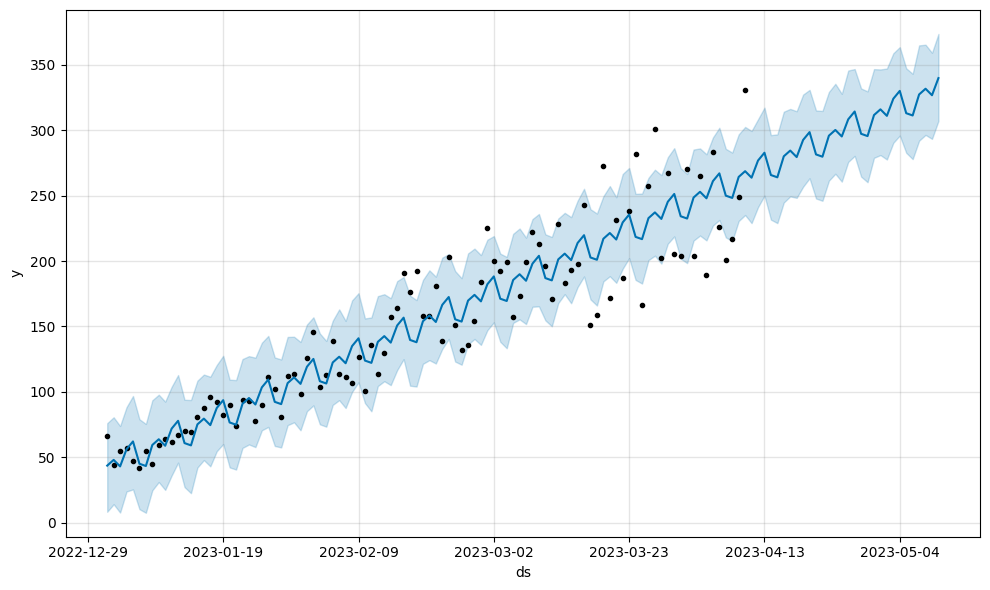

In [192]:
import matplotlib.pyplot as plt

# Plot forecast
fig = model.plot(forecast)
plt.show()

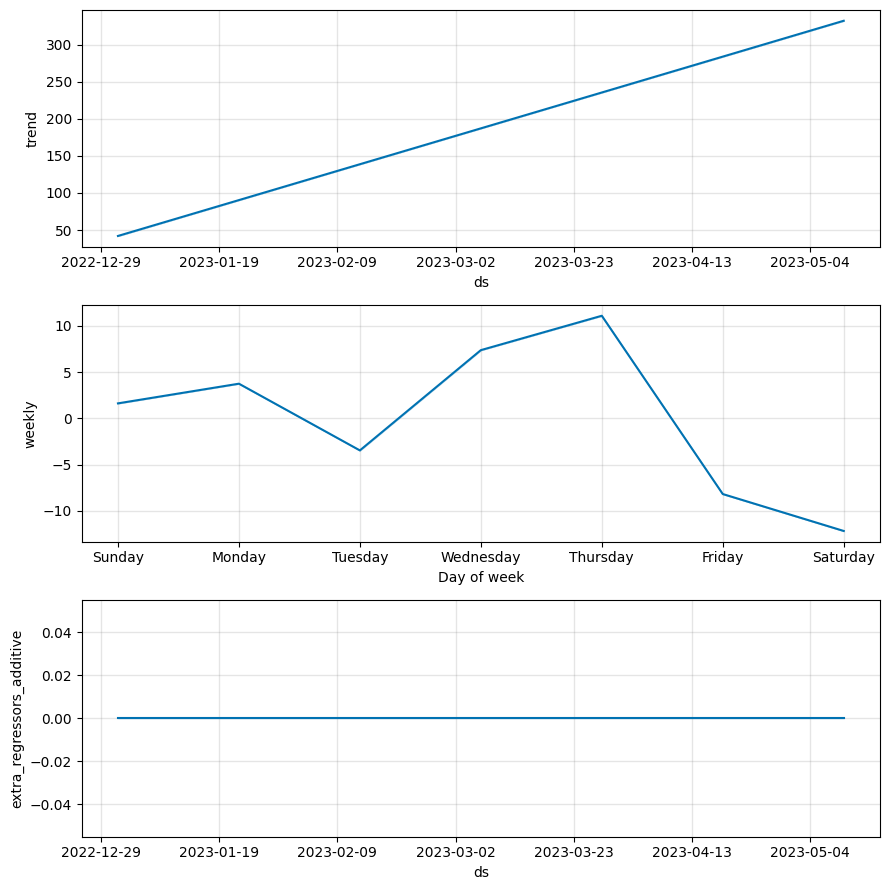

In [193]:
# Plot forecast components (trend, seasonality, effect of temp)
fig2 = model.plot_components(forecast)
plt.show()

In [198]:
from prophet import Prophet
from sklearn.model_selection import ParameterGrid
import numpy as np

# Define hyperparameter grid
param_grid = {
    "changepoint_prior_scale": [0.0001, 0.0005, 0.001, 0.01],
    "seasonality_prior_scale": [0.1, 0.15, 0.2, 0.25, 1.0],
    "seasonality_mode": ["additive", "multiplicative"]
}

# Create all combinations of parameters
grid = list(ParameterGrid(param_grid))

# Split dataset for cross-validation
split_point = int(len(df_prophet) * 0.8)  # 80% train, 20% test
train_df = df_prophet[:split_point]
test_df = df_prophet[split_point:]

best_model = None
best_mse = float("inf")
best_params = None

for params in grid:
    # Initialize and fit model
    model = Prophet(
        changepoint_prior_scale=params["changepoint_prior_scale"],
        seasonality_prior_scale=params["seasonality_prior_scale"],
        seasonality_mode=params["seasonality_mode"]
    )
    model.add_regressor("temp")
    model.fit(train_df)
    
    # Make future dataframe
    future = model.make_future_dataframe(periods=len(test_df))
    future["temp"] = test_df["temp"].mean()  # Use actual future temperature values

    # Predict
    forecast = model.predict(future)
    
    # Calculate error (Mean Squared Error)
    mse = np.mean((forecast["yhat"].iloc[-len(test_df):].values - test_df["y"].values) ** 2)
    
    # Save the best model
    if mse < best_mse:
        best_mse = mse
        best_model = model
        best_params = params

print("Best Parameters:", best_params)
print("Best MSE:", best_mse)

10:49:37 - cmdstanpy - INFO - Chain [1] start processing
10:49:37 - cmdstanpy - INFO - Chain [1] done processing
10:49:37 - cmdstanpy - INFO - Chain [1] start processing
10:49:37 - cmdstanpy - INFO - Chain [1] done processing
10:49:37 - cmdstanpy - INFO - Chain [1] start processing
10:49:37 - cmdstanpy - INFO - Chain [1] done processing
10:49:38 - cmdstanpy - INFO - Chain [1] start processing
10:49:38 - cmdstanpy - INFO - Chain [1] done processing
10:49:38 - cmdstanpy - INFO - Chain [1] start processing
10:49:50 - cmdstanpy - INFO - Chain [1] done processing
10:49:50 - cmdstanpy - INFO - Chain [1] start processing
10:49:50 - cmdstanpy - INFO - Chain [1] done processing
10:49:50 - cmdstanpy - INFO - Chain [1] start processing
10:49:50 - cmdstanpy - INFO - Chain [1] done processing
10:49:51 - cmdstanpy - INFO - Chain [1] start processing
10:49:51 - cmdstanpy - INFO - Chain [1] done processing
10:49:51 - cmdstanpy - INFO - Chain [1] start processing
10:49:51 - cmdstanpy - INFO - Chain [1]

Best Parameters: {'changepoint_prior_scale': 0.0001, 'seasonality_mode': 'multiplicative', 'seasonality_prior_scale': 0.1}
Best MSE: 2530.9850687791095


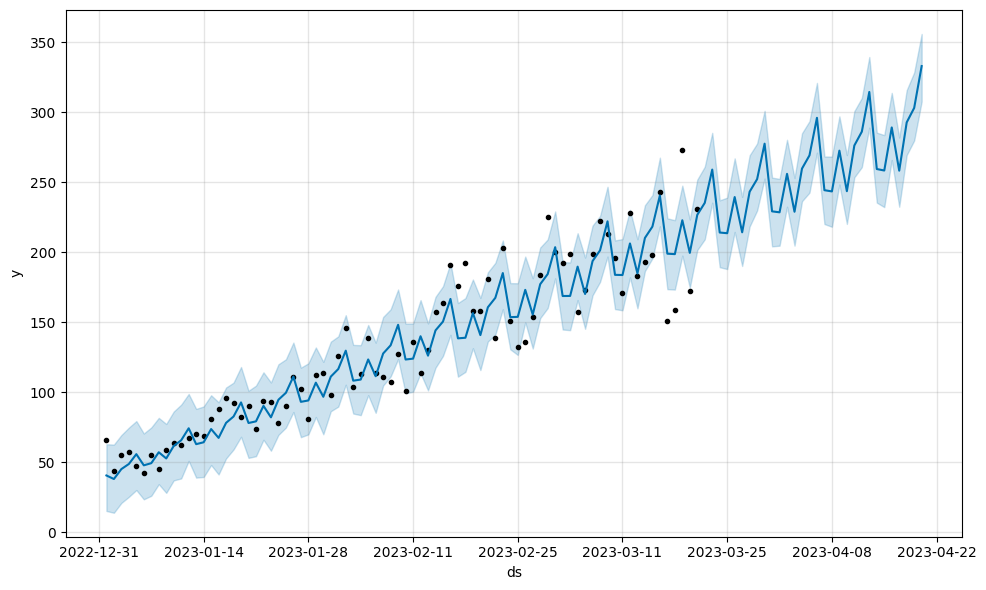

In [199]:
import matplotlib.pyplot as plt

# Predict using the best model
future = best_model.make_future_dataframe(periods=30)
future["temp"] = df_prophet["temp"].mean()  # Assuming avg temperature

forecast = best_model.predict(future)

# Plot the forecast
best_model.plot(forecast)
plt.show()

In [204]:
from prophet.diagnostics import cross_validation, performance_metrics

# Adjust parameters for small dataset
df_cv = cross_validation(best_model, 
                         horizon="5 days",   # Reduce forecast window
                         period="3 days",    # Reduce step size
                         initial="60 days")  # Ensure training window fits data

# Evaluate performance
df_perf = performance_metrics(df_cv)
df_perf.head()

  0%|          | 0/5 [00:00<?, ?it/s]

10:51:44 - cmdstanpy - INFO - Chain [1] start processing
10:51:44 - cmdstanpy - INFO - Chain [1] done processing
10:51:44 - cmdstanpy - INFO - Chain [1] start processing
10:51:45 - cmdstanpy - INFO - Chain [1] done processing
10:51:45 - cmdstanpy - INFO - Chain [1] start processing
10:51:47 - cmdstanpy - INFO - Chain [1] done processing
10:51:47 - cmdstanpy - INFO - Chain [1] start processing
10:51:48 - cmdstanpy - INFO - Chain [1] done processing
10:51:48 - cmdstanpy - INFO - Chain [1] start processing
10:51:49 - cmdstanpy - INFO - Chain [1] done processing


,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,1 days,1005.903458,31.715981,29.539515,0.173534,0.149456,0.158395,0.2
1,2 days,915.518534,30.257537,26.644935,0.140191,0.168574,0.134038,0.4
2,3 days,788.061130,28.072427,18.470853,0.077332,0.026345,0.081511,0.6
3,4 days,1749.731919,41.829797,37.812779,0.221583,0.204176,0.194999,0.2
4,5 days,1220.935829,34.941892,29.259848,0.156065,0.151718,0.143820,0.4


### Product 3

In [250]:
# Rename columns for FBProphet
df_prophet = df.rename(columns={"t": "ds", "ProductP3": "y", "temperature": "temp"})

# Convert 'ds' into a proper datetime format (assuming 't' represents sequential days)
df_prophet["ds"] = pd.date_range(start="2023-01-01", periods=len(df_prophet), freq="D")

# Keep only necessary columns
df_prophet = df_prophet[["ds", "y", "temp"]]

In [251]:
# Initialize Prophet model
model = Prophet()
model.add_regressor("temp")  # Add temperature as an external regressor
# Fit the model
model.fit(df_prophet)

# Create future dataframe (next 30 days)
future = model.make_future_dataframe(periods=30)
future["temp"] = df_prophet["temp"].mean()  # Assuming average temperature for future predictions

# Forecast
forecast = model.predict(future)

12:22:42 - cmdstanpy - INFO - Chain [1] start processing
12:22:42 - cmdstanpy - INFO - Chain [1] done processing


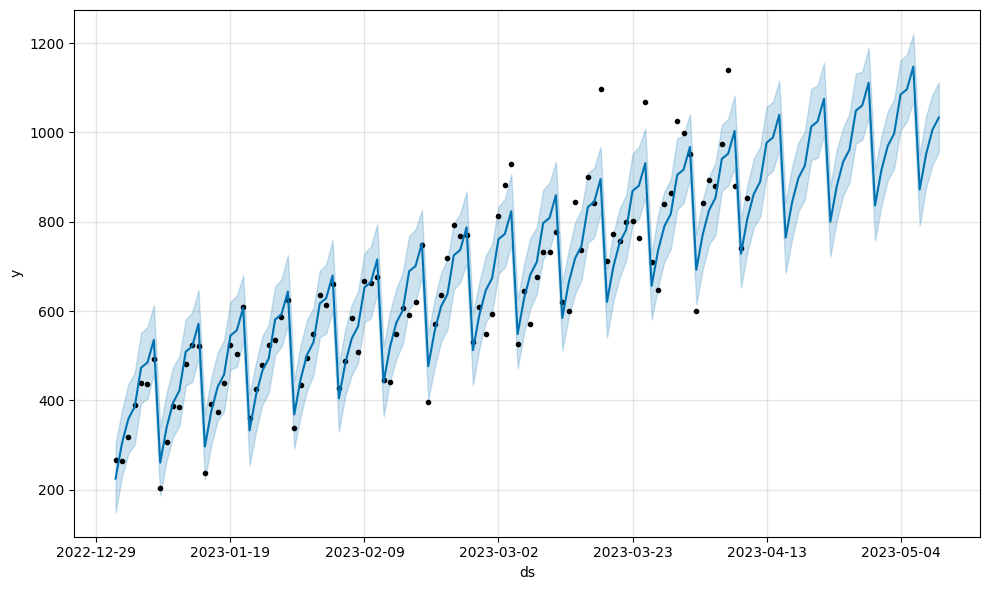

In [252]:
# Plot forecast
fig = model.plot(forecast)
plt.show()

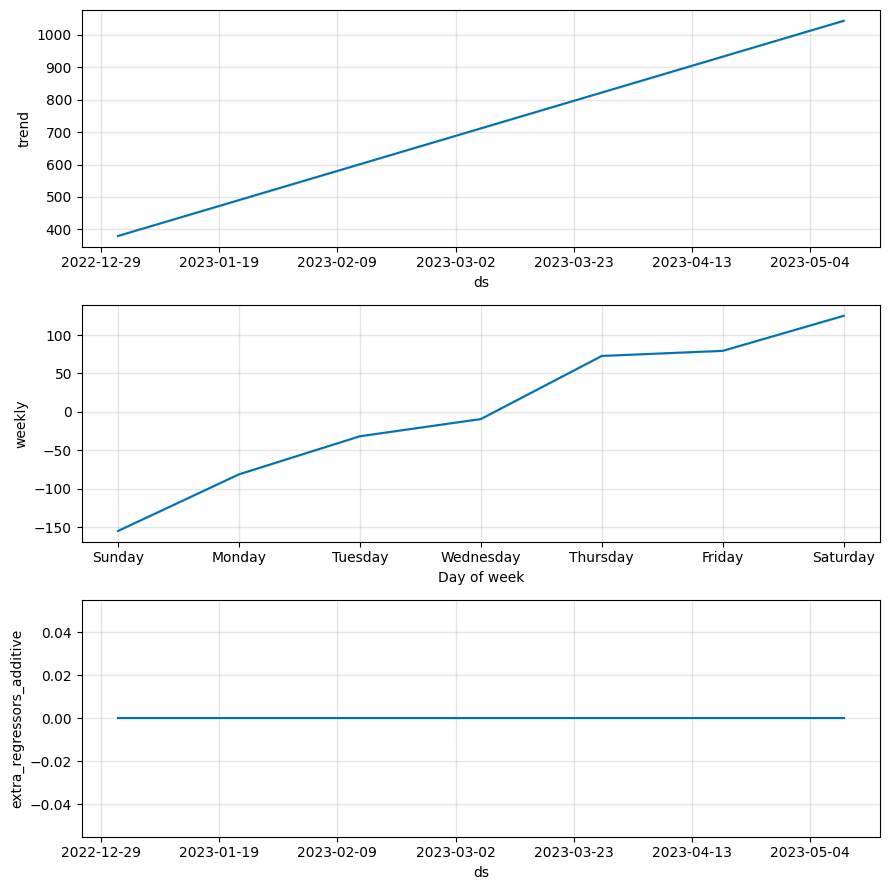

In [253]:
# Plot forecast components (trend, seasonality, effect of temp)
fig2 = model.plot_components(forecast)
plt.show()

In [254]:
from prophet import Prophet
from sklearn.model_selection import ParameterGrid
import numpy as np

# Define hyperparameter grid
param_grid = {
    "changepoint_prior_scale": [0.0005, 0.001, 0.0015, 0.002, 0.0025, 0.003],
    "seasonality_prior_scale": [0.1, 0.15, 0.2, 0.25, 1.0],
    "seasonality_mode": ["additive", "multiplicative"]
}

# Create all combinations of parameters
grid = list(ParameterGrid(param_grid))

# Split dataset for cross-validation
split_point = int(len(df_prophet) * 0.8)  # 80% train, 20% test
train_df = df_prophet[:split_point]
test_df = df_prophet[split_point:]

best_model = None
best_mse = float("inf")
best_params = None

for params in grid:
    # Initialize and fit model
    model = Prophet(
        changepoint_prior_scale=params["changepoint_prior_scale"],
        seasonality_prior_scale=params["seasonality_prior_scale"],
        seasonality_mode=params["seasonality_mode"]
    )
    model.add_regressor("temp")
    model.fit(train_df)
    
    # Make future dataframe
    future = model.make_future_dataframe(periods=len(test_df))
    future["temp"] = np.concatenate([train_df["temp"].values, test_df["temp"].values])  # Ensure it has correct length
    
    # Predict
    forecast = model.predict(future)
    
    # Calculate error (Mean Squared Error)
    mse = np.mean((forecast["yhat"].iloc[-len(test_df):].values - test_df["y"].values) ** 2)
    
    # Save the best model
    if mse < best_mse:
        best_mse = mse
        best_model = model
        best_params = params

print("Best Parameters:", best_params)
print("Best MSE:", best_mse)

12:23:11 - cmdstanpy - INFO - Chain [1] start processing
12:23:11 - cmdstanpy - INFO - Chain [1] done processing
12:23:12 - cmdstanpy - INFO - Chain [1] start processing
12:23:12 - cmdstanpy - INFO - Chain [1] done processing
12:23:12 - cmdstanpy - INFO - Chain [1] start processing
12:23:12 - cmdstanpy - INFO - Chain [1] done processing
12:23:12 - cmdstanpy - INFO - Chain [1] start processing
12:23:13 - cmdstanpy - INFO - Chain [1] done processing
12:23:13 - cmdstanpy - INFO - Chain [1] start processing
12:23:13 - cmdstanpy - INFO - Chain [1] done processing
12:23:13 - cmdstanpy - INFO - Chain [1] start processing
12:23:13 - cmdstanpy - INFO - Chain [1] done processing
12:23:13 - cmdstanpy - INFO - Chain [1] start processing
12:23:14 - cmdstanpy - INFO - Chain [1] done processing
12:23:14 - cmdstanpy - INFO - Chain [1] start processing
12:23:14 - cmdstanpy - INFO - Chain [1] done processing
12:23:14 - cmdstanpy - INFO - Chain [1] start processing
12:23:14 - cmdstanpy - INFO - Chain [1]

Best Parameters: {'changepoint_prior_scale': 0.001, 'seasonality_mode': 'additive', 'seasonality_prior_scale': 0.15}
Best MSE: 7177.896711307194


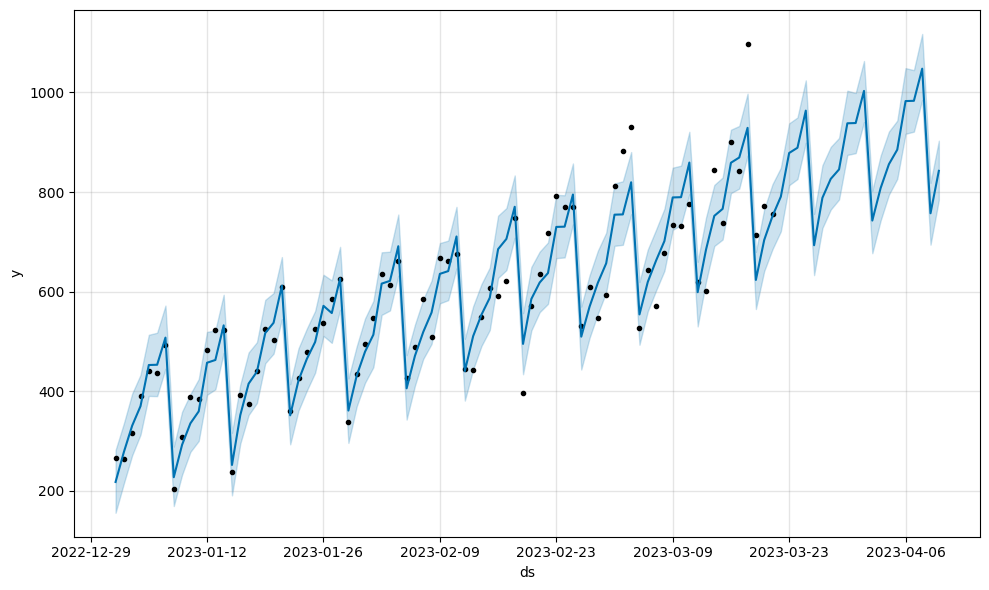

In [256]:
import matplotlib.pyplot as plt

# Predict using the best model
future = best_model.make_future_dataframe(periods=20)
future["temp"] = np.concatenate([train_df["temp"].values, test_df["temp"].values])  # Assuming avg temperature

forecast = best_model.predict(future)

# Plot the forecast
best_model.plot(forecast)
plt.show()

In [257]:
from prophet.diagnostics import cross_validation, performance_metrics

# Adjust parameters for small dataset
df_cv = cross_validation(best_model, 
                         horizon="10 days",   # Reduce forecast window
                         period="3 days",    # Reduce step size
                         initial="60 days")  # Ensure training window fits data

# Evaluate performance
df_perf = performance_metrics(df_cv)
df_perf

  0%|          | 0/4 [00:00<?, ?it/s]

12:24:15 - cmdstanpy - INFO - Chain [1] start processing
12:24:15 - cmdstanpy - INFO - Chain [1] done processing
12:24:15 - cmdstanpy - INFO - Chain [1] start processing
12:24:16 - cmdstanpy - INFO - Chain [1] done processing
12:24:16 - cmdstanpy - INFO - Chain [1] start processing
12:24:17 - cmdstanpy - INFO - Chain [1] done processing
12:24:17 - cmdstanpy - INFO - Chain [1] start processing
12:24:18 - cmdstanpy - INFO - Chain [1] done processing


,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,1 days,5871.190306,76.623693,63.598655,0.082530,0.078664,0.085216,0.50
1,2 days,9708.674087,98.532604,95.585700,0.136315,0.129273,0.132254,0.00
2,3 days,5826.096809,76.328873,64.710114,0.084511,0.081591,0.085473,0.50
3,4 days,1638.699803,40.480857,35.748861,0.051932,0.045638,0.051388,0.75
4,5 days,6230.329565,78.932437,78.103591,0.117637,0.119620,0.111743,0.00
5,6 days,5412.554854,73.570068,60.634034,0.076184,0.076114,0.077101,0.50
6,7 days,11106.645299,105.388070,78.043101,0.085758,0.063515,0.089643,0.50
7,8 days,5745.695387,75.800365,72.045461,0.102176,0.102364,0.102970,0.25
8,9 days,5407.703604,73.537090,67.436897,0.083551,0.088028,0.086165,0.25
9,10 days,9093.828876,95.361569,68.319371,0.074459,0.050043,0.078636,0.75


In [387]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.vector_ar.vecm import VECM, select_order
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.vector_ar.vecm import coint_johansen

In [498]:
# Rename columns for FBProphet
df_vecm = df.rename(columns={"t": "date", "ProductP3": "ProductP3", "ProductP4": "ProductP4", "temperature": "temperature"})

# Convert 'ds' into a proper datetime format (assuming 't' represents sequential days)
df_vecm["date"] = pd.date_range(start="2023-01-01", periods=len(df_vecm), freq="D")

# Keep only necessary columns
df_vecm = df_vecm[["date", "ProductP3", "ProductP4", "temperature"]]
df_vecm.set_index('date', inplace=True)

In [499]:
df_vecm.head()

,ProductP3,ProductP4,temperature
date,,,
2023-01-01,266,113,18
2023-01-02,264,74,21
2023-01-03,317,116,19
2023-01-04,390,70,17
2023-01-05,440,141,18


In [500]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

# Perform Johansen cointegration test
result = coint_johansen(df_vecm[['ProductP3', 'ProductP4']], det_order=0, k_ar_diff=1)
print("Johansen Cointegration Test Results:")
print("Test Statistics:", result.lr1)
print("Critical Values (90%, 95%, 99%):", result.cvt)

Johansen Cointegration Test Results:
Test Statistics: [66.57336318  9.7023805 ]
Critical Values (90%, 95%, 99%): [[13.4294 15.4943 19.9349]
 [ 2.7055  3.8415  6.6349]]


In [501]:
from statsmodels.tsa.vector_ar.vecm import VECM

# Fit VECM model
model = VECM(df_vecm[['ProductP3', 'ProductP4', 'temperature']], coint_rank=1, k_ar_diff=1)
results = model.fit()

# Display model summary
print(results.summary())

Det. terms outside the coint. relation & lagged endog. parameters for equation ProductP3
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
L1.ProductP3      -0.2579      0.102     -2.518      0.012      -0.459      -0.057
L1.ProductP4       0.6513      0.355      1.833      0.067      -0.045       1.348
L1.temperature    -2.7114      6.801     -0.399      0.690     -16.041      10.618
Det. terms outside the coint. relation & lagged endog. parameters for equation ProductP4
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
L1.ProductP3       0.0251      0.028      0.896      0.370      -0.030       0.080
L1.ProductP4       0.0151      0.097      0.156      0.876      -0.176       0.206
L1.temperature    -1.0483      1.863     -0.563      0.574      -4.700     

C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [502]:
# Forecast the next 30 days
forecast_steps = 30
forecast = results.predict(steps=forecast_steps)

# Create a DataFrame for the forecast
forecast_dates = pd.date_range(start=df_vecm.index[-1] + pd.Timedelta(days=1), periods=forecast_steps, freq='D')
forecast_df = pd.DataFrame(forecast, index=forecast_dates, columns=df_vecm.columns)

# Display the forecast
print(forecast_df.head())

             ProductP3  ProductP4  temperature
2023-04-11  833.583577  79.487510     5.054977
2023-04-12  842.212781  72.298463     5.049690
2023-04-13  835.181078  73.981141     5.070089
2023-04-14  838.096354  73.114695     5.060627
2023-04-15  836.768762  73.605151     5.064256


In [503]:
from sklearn.metrics import mean_absolute_error

# Train-test split
train_data = df_vecm.iloc[:-30]  # Use all but the last 30 days for training
test_data = df_vecm.iloc[-30:]   # Last 30 days for testing

# Fit the VECM model on the training data
model_train = VECM(train_data[['ProductP3', 'ProductP4', 'temperature']], coint_rank=1, k_ar_diff=1)
results_train = model_train.fit()

# Forecast on the test data
forecast_test = results_train.predict(steps=30)

# Calculate MAE
mae = mean_absolute_error(test_data['ProductP3'], forecast_test[:, 0])
print(f'Mean Absolute Error (MAE): {mae}')

Mean Absolute Error (MAE): 129.3953240524884


C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


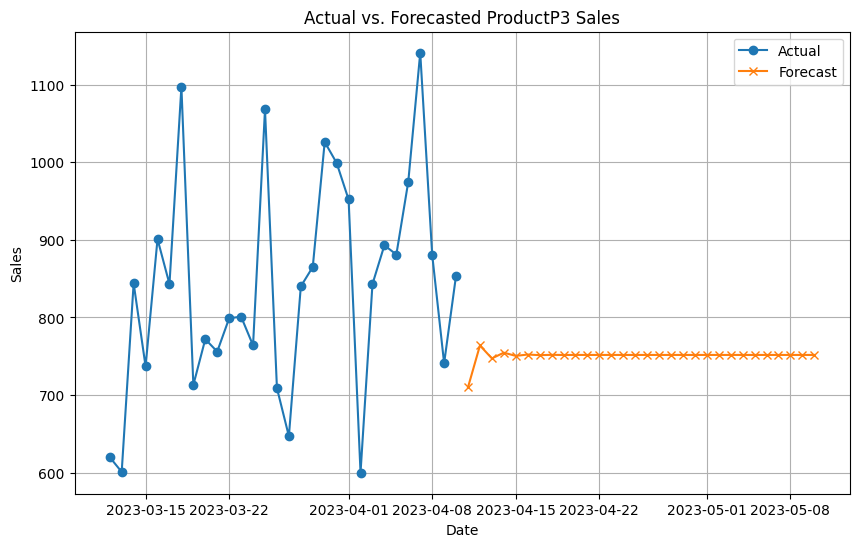

In [504]:
import matplotlib.pyplot as plt

# Plot actual vs. forecasted values
plt.figure(figsize=(10, 6))
plt.plot(test_data.index, test_data['ProductP3'], label='Actual', marker='o')
plt.plot(forecast_dates, forecast_test[:, 0], label='Forecast', marker='x')
plt.title('Actual vs. Forecasted ProductP3 Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid()
plt.show()

In [474]:
param_grid = {
    'coint_rank': [1, 2, 3, 4,5,6,7,8,9,10],  # Test for 1 or 2 cointegrating relationships
    'k_ar_diff': [1, 2, 3, 4, 5],  # Test for 1, 2, or 3 lags
    'deterministic': ['nc', 'co', 'lo']  # No constant, constant in cointegration, linear trend in cointegration
}

In [505]:
# Step 3: Perform Grid Search
best_aic = float('inf')
best_params = None

for params in itertools.product(*param_grid.values()):
    coint_rank, k_ar_diff, deterministic = params
    try:
        # Fit VECM model
        model = VECM(df_vecm[['ProductP3', 'ProductP4', 'temperature']],
                     coint_rank=coint_rank,
                     k_ar_diff=k_ar_diff,
                     deterministic=deterministic)
        results = model.fit()

        # Compute AIC manually
        llf = results.llf  # Log-likelihood

        # Calculate the number of parameters
        n_vars = len(data.columns)  # Number of variables
        n_lags = k_ar_diff  # Number of lags
        n_coint = coint_rank  # Cointegration rank
        n_params = n_vars * n_lags + n_coint * n_vars  # Total number of parameters

        aic = -2 * llf + 2 * n_params

        print(f"Params: {params}, AIC: {aic}")

        # Update best parameters if current model is better
        if aic < best_aic:
            best_aic = aic
            best_params = params
    except Exception as e:
        print(f"Error with params {params}: {e}")

print(f"Best Parameters: {best_params}, Best AIC: {best_aic}")

C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No f

Params: (1, 1, 'nc'), AIC: 2638.991703256416
Params: (1, 1, 'co'), AIC: 2619.3013548721437
Params: (1, 1, 'lo'), AIC: 2617.698427143347
Params: (1, 2, 'nc'), AIC: 2598.313976867639
Params: (1, 2, 'co'), AIC: 2567.1400177944693
Params: (1, 2, 'lo'), AIC: 2555.8618181791826
Params: (1, 3, 'nc'), AIC: 2532.2505012059364
Params: (1, 3, 'co'), AIC: 2507.2568608415627
Params: (1, 3, 'lo'), AIC: 2506.0804493381247
Params: (1, 4, 'nc'), AIC: 2477.076121207759
Params: (1, 4, 'co'), AIC: 2464.6766382914807
Params: (1, 4, 'lo'), AIC: 2453.2057878885175
Params: (1, 5, 'nc'), AIC: 2424.695122052664
Params: (1, 5, 'co'), AIC: 2415.4525424231397
Params: (1, 5, 'lo'), AIC: 2405.118863350283
Params: (2, 1, 'nc'), AIC: 2642.5932991001473
Params: (2, 1, 'co'), AIC: 2597.403556005626
Params: (2, 1, 'lo'), AIC: 2592.746391808165
Params: (2, 2, 'nc'), AIC: 2602.805805213722
Params: (2, 2, 'co'), AIC: 2552.0203259352184
Params: (2, 2, 'lo'), AIC: 2533.684973270643
Params: (2, 3, 'nc'), AIC: 2537.692473235317

C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No f

Params: (6, 4, 'lo'), AIC: 2474.6584473475573
Params: (6, 5, 'nc'), AIC: 2459.310248781072
Params: (6, 5, 'co'), AIC: 2444.6589847397104
Params: (6, 5, 'lo'), AIC: 2429.1920697733185
Params: (7, 1, 'nc'), AIC: 2682.1721444341024
Params: (7, 1, 'co'), AIC: 2634.347440623838
Params: (7, 1, 'lo'), AIC: 2631.9172571323284
Params: (7, 2, 'nc'), AIC: 2642.464363091761
Params: (7, 2, 'co'), AIC: 2590.2369548568045
Params: (7, 2, 'lo'), AIC: 2573.4439641223184
Params: (7, 3, 'nc'), AIC: 2577.5239145540513
Params: (7, 3, 'co'), AIC: 2537.269400238604
Params: (7, 3, 'lo'), AIC: 2531.875063609281
Params: (7, 4, 'nc'), AIC: 2520.2968569865975
Params: (7, 4, 'co'), AIC: 2492.8071161532316
Params: (7, 4, 'lo'), AIC: 2482.6584473475573
Params: (7, 5, 'nc'), AIC: 2467.310248781072
Params: (7, 5, 'co'), AIC: 2452.6589847397104
Params: (7, 5, 'lo'), AIC: 2437.1920697733185
Params: (8, 1, 'nc'), AIC: 2690.1721444341024
Params: (8, 1, 'co'), AIC: 2642.347440623838
Params: (8, 1, 'lo'), AIC: 2639.917257132

C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No f

Params: (10, 1, 'lo'), AIC: 2655.9172571323284
Params: (10, 2, 'nc'), AIC: 2666.464363091761
Params: (10, 2, 'co'), AIC: 2614.2369548568045
Params: (10, 2, 'lo'), AIC: 2597.4439641223184
Params: (10, 3, 'nc'), AIC: 2601.5239145540513
Params: (10, 3, 'co'), AIC: 2561.269400238604
Params: (10, 3, 'lo'), AIC: 2555.875063609281
Params: (10, 4, 'nc'), AIC: 2544.2968569865975
Params: (10, 4, 'co'), AIC: 2516.8071161532316
Params: (10, 4, 'lo'), AIC: 2506.6584473475573
Params: (10, 5, 'nc'), AIC: 2491.310248781072
Params: (10, 5, 'co'), AIC: 2476.6589847397104
Params: (10, 5, 'lo'), AIC: 2461.1920697733185
Best Parameters: (2, 5, 'lo'), Best AIC: 2397.1964534020854


C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No f

In [506]:
# Step 4: Fit the Best Model
best_coint_rank, best_k_ar_diff, best_deterministic = best_params
best_model = VECM(df_vecm[['ProductP3', 'ProductP4', 'temperature']],
                  coint_rank=best_coint_rank,
                  k_ar_diff=best_k_ar_diff,
                  deterministic=best_deterministic)
best_results = best_model.fit()

C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [507]:
# Display summary of the best model
print(best_results.summary())

Det. terms outside the coint. relation & lagged endog. parameters for equation ProductP3
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
lin_trend          7.7329      2.335      3.311      0.001       3.156      12.310
L1.ProductP3       0.2444      0.289      0.845      0.398      -0.322       0.811
L1.ProductP4      -1.5256      0.775     -1.968      0.049      -3.045      -0.006
L1.temperature    -2.9042      5.070     -0.573      0.567     -12.842       7.034
L2.ProductP3       0.1564      0.250      0.626      0.531      -0.333       0.646
L2.ProductP4      -1.5020      0.682     -2.202      0.028      -2.839      -0.165
L2.temperature    -6.6336      5.194     -1.277      0.202     -16.813       3.546
L3.ProductP3       0.0086      0.213      0.040      0.968      -0.410       0.427
L3.ProductP4      -2.0267      0.560     -3.622      0.000      -3.123      -0.93

In [508]:
# Step 5: Validate the Model
train_data = df_vecm.iloc[:-30]  # Use all but the last 30 days for training
test_data = df_vecm.iloc[-30:]   # Last 30 days for testing

In [509]:
# Fit the best model on the training data
best_model_train = VECM(train_data[['ProductP3', 'ProductP4', 'temperature']],
                        coint_rank=best_coint_rank,
                        k_ar_diff=best_k_ar_diff,
                        deterministic=best_deterministic)
best_results_train = best_model_train.fit()

C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [510]:
# Forecast on the test data
forecast_test = best_results_train.predict(steps=30)

In [511]:
# Calculate MAE
mae = mean_absolute_error(test_data['ProductP3'], forecast_test[:, 0])
print(f'Mean Absolute Error (MAE): {mae}')

Mean Absolute Error (MAE): 90.50853289588238


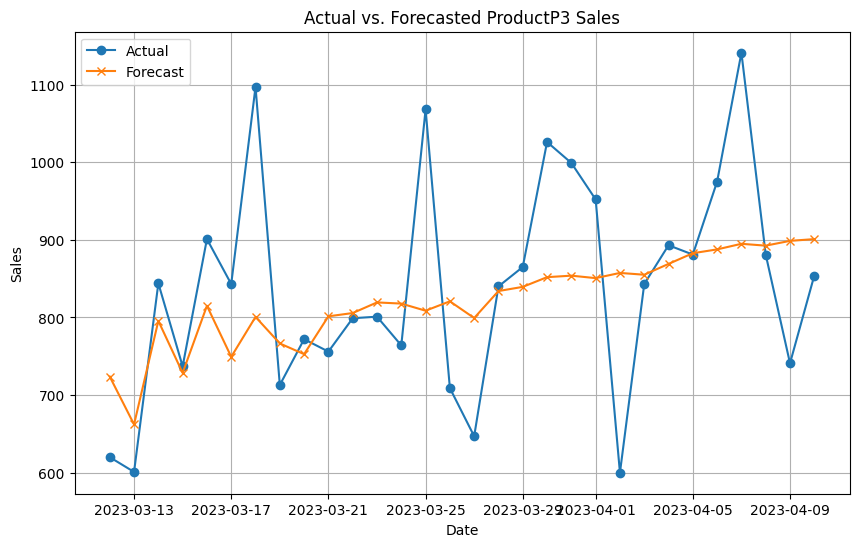

In [512]:
# Step 6: Visualize Results
plt.figure(figsize=(10, 6))
plt.plot(test_data.index, test_data['ProductP3'], label='Actual', marker='o')
plt.plot(test_data.index, forecast_test[:, 0], label='Forecast', marker='x')
plt.title('Actual vs. Forecasted ProductP3 Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid()
plt.show()

### Product 4

In [261]:
# Rename columns for FBProphet
df_prophet = df.rename(columns={"t": "ds", "ProductP4": "y"})

# Convert 'ds' into a proper datetime format (assuming 't' represents sequential days)
df_prophet["ds"] = pd.date_range(start="2023-01-01", periods=len(df_prophet), freq="D")

# Keep only necessary columns
df_prophet = df_prophet[["ds", "y"]]

In [262]:
# Initialize Prophet model
model = Prophet()
# model.add_regressor("temp")  # Add temperature as an external regressor

# Fit the model
model.fit(df_prophet)

# Create future dataframe (next 30 days)
future = model.make_future_dataframe(periods=30)
# future["temp"] = df_prophet["temp"].mean()  # Assuming average temperature for future predictions

# Forecast
forecast = model.predict(future)

12:34:23 - cmdstanpy - INFO - Chain [1] start processing
12:34:23 - cmdstanpy - INFO - Chain [1] done processing


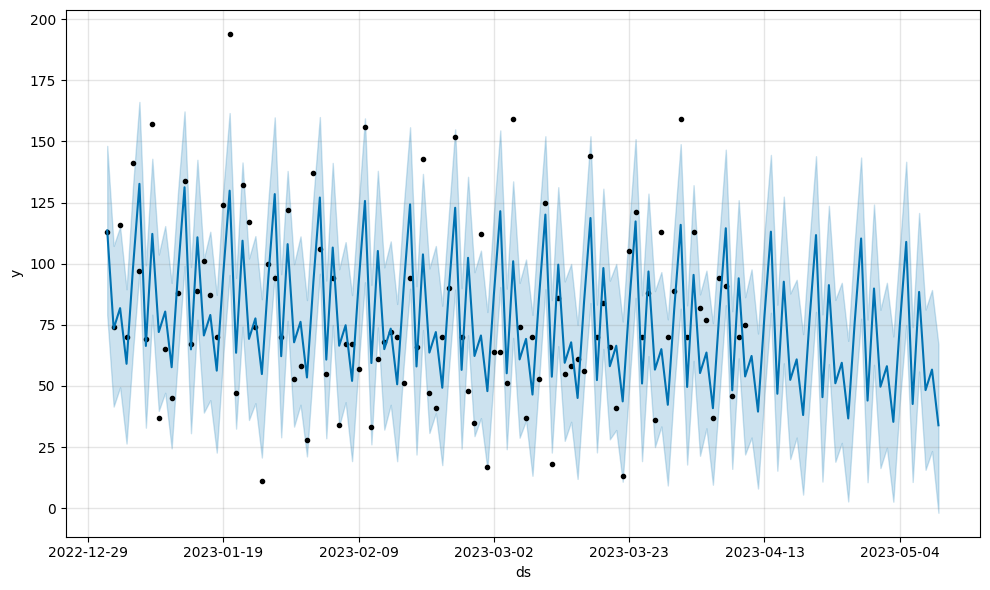

In [263]:
# Plot forecast
fig = model.plot(forecast)
plt.show()

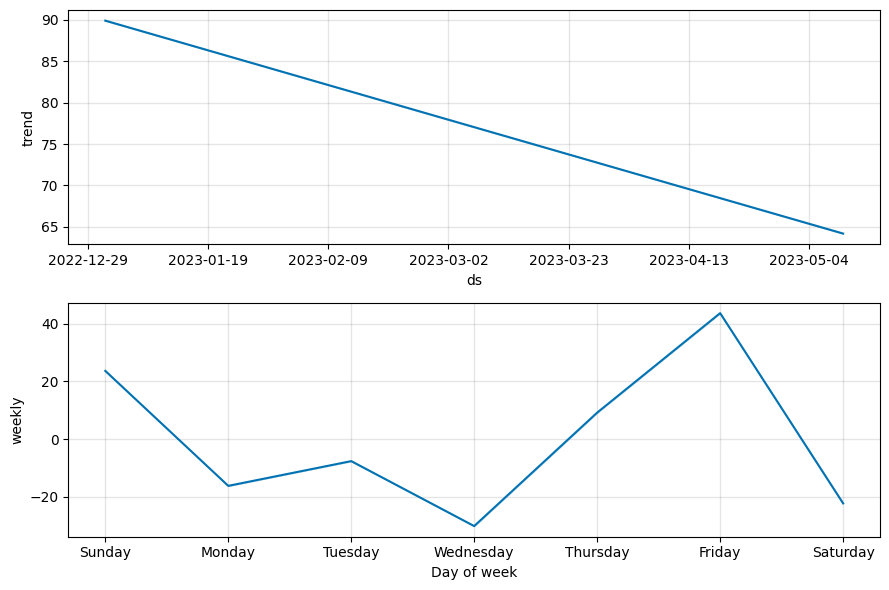

In [264]:
# Plot forecast components (trend, seasonality, effect of temp)
fig2 = model.plot_components(forecast)
plt.show()

In [267]:
from prophet import Prophet
from sklearn.model_selection import ParameterGrid
import numpy as np

# Define hyperparameter grid
param_grid = {
    "changepoint_prior_scale": [0.5, 0.6, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0],
    "seasonality_prior_scale": [10.0, 20.0, 25.0, 30.0, 35.0, 40.0],
    "seasonality_mode": ["additive", "multiplicative"]
}

# Create all combinations of parameters
grid = list(ParameterGrid(param_grid))

# Split dataset for cross-validation
split_point = int(len(df_prophet) * 0.8)  # 80% train, 20% test
train_df = df_prophet[:split_point]
test_df = df_prophet[split_point:]

best_model = None
best_mse = float("inf")
best_params = None

for params in grid:
    # Initialize and fit model
    model = Prophet(
        changepoint_prior_scale=params["changepoint_prior_scale"],
        seasonality_prior_scale=params["seasonality_prior_scale"],
        seasonality_mode=params["seasonality_mode"]
    )
    # model.add_regressor("temp")
    model.fit(train_df)
    
    # Make future dataframe
    future = model.make_future_dataframe(periods=len(test_df))
    # future["temp"] = test_df["temp"].values  # Use actual future temperature values

    # Predict
    forecast = model.predict(future)
    
    # Calculate error (Mean Squared Error)
    mse = np.mean((forecast["yhat"].iloc[-len(test_df):].values - test_df["y"].values) ** 2)
    
    # Save the best model
    if mse < best_mse:
        best_mse = mse
        best_model = model
        best_params = params

print("Best Parameters:", best_params)
print("Best MSE:", best_mse)

12:37:35 - cmdstanpy - INFO - Chain [1] start processing
12:37:36 - cmdstanpy - INFO - Chain [1] done processing
12:37:36 - cmdstanpy - INFO - Chain [1] start processing
12:37:36 - cmdstanpy - INFO - Chain [1] done processing
12:37:36 - cmdstanpy - INFO - Chain [1] start processing
12:37:37 - cmdstanpy - INFO - Chain [1] done processing
12:37:37 - cmdstanpy - INFO - Chain [1] start processing
12:37:37 - cmdstanpy - INFO - Chain [1] done processing
12:37:37 - cmdstanpy - INFO - Chain [1] start processing
12:37:38 - cmdstanpy - INFO - Chain [1] done processing
12:37:38 - cmdstanpy - INFO - Chain [1] start processing
12:37:38 - cmdstanpy - INFO - Chain [1] done processing
12:37:38 - cmdstanpy - INFO - Chain [1] start processing
12:37:38 - cmdstanpy - INFO - Chain [1] done processing
12:37:39 - cmdstanpy - INFO - Chain [1] start processing
12:37:39 - cmdstanpy - INFO - Chain [1] done processing
12:37:39 - cmdstanpy - INFO - Chain [1] start processing
12:37:39 - cmdstanpy - INFO - Chain [1]

Best Parameters: {'changepoint_prior_scale': 0.85, 'seasonality_mode': 'multiplicative', 'seasonality_prior_scale': 20.0}
Best MSE: 618.3736483082249


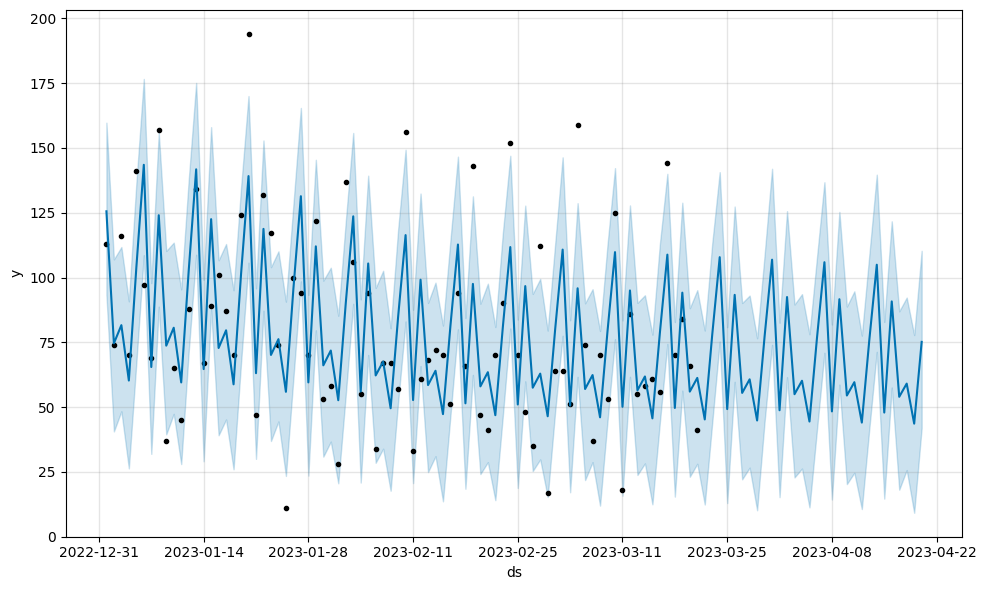

In [268]:
# Predict using the best model
future = best_model.make_future_dataframe(periods=30)
# future["temp"] = df_prophet["temp"].mean()  # Assuming avg temperature

forecast = best_model.predict(future)

# Plot the forecast
best_model.plot(forecast)
plt.show()

In [272]:
# Adjust parameters for small dataset
df_cv = cross_validation(best_model, 
                         horizon="10 days",   # Reduce forecast window
                         period="2 days",    # Reduce step size
                         initial="60 days")  # Ensure training window fits data

# Evaluate performance
df_perf = performance_metrics(df_cv)
df_perf

  0%|          | 0/5 [00:00<?, ?it/s]

12:39:55 - cmdstanpy - INFO - Chain [1] start processing
12:39:56 - cmdstanpy - INFO - Chain [1] done processing
12:39:56 - cmdstanpy - INFO - Chain [1] start processing
12:39:56 - cmdstanpy - INFO - Chain [1] done processing
12:39:56 - cmdstanpy - INFO - Chain [1] start processing
12:39:56 - cmdstanpy - INFO - Chain [1] done processing
12:39:56 - cmdstanpy - INFO - Chain [1] start processing
12:39:57 - cmdstanpy - INFO - Chain [1] done processing
12:39:57 - cmdstanpy - INFO - Chain [1] start processing
12:39:57 - cmdstanpy - INFO - Chain [1] done processing


,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,1 days,344.297325,18.555251,16.607572,0.207838,0.185713,0.238357,1.0
1,2 days,1822.344799,42.688931,34.321802,0.726355,0.556648,0.525776,0.8
2,3 days,377.168944,19.420838,16.794452,0.208757,0.164629,0.243975,1.0
3,4 days,560.449540,23.673815,20.662114,0.650034,0.513984,0.438945,1.0
4,5 days,399.956051,19.998901,16.876890,0.233018,0.131102,0.251664,0.8
5,6 days,702.868430,26.511666,22.266807,0.567505,0.304903,0.390195,0.6
6,7 days,515.276712,22.699707,19.945618,0.248171,0.298924,0.257648,0.8
7,8 days,598.546216,24.465204,19.432123,0.410653,0.310650,0.330205,0.8
8,9 days,307.565447,17.537544,16.462994,0.255007,0.190094,0.253590,1.0
9,10 days,507.976989,22.538345,19.080118,0.265001,0.279810,0.269152,0.8


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.vector_ar.vecm import VECM, select_order
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.vector_ar.vecm import coint_johansen

In [483]:
# Rename columns for FBProphet
df_vecm = df.rename(columns={"t": "date", "ProductP4": "ProductP4", "ProductP3": "ProductP3", "temperature": "temperature", "price": "price"})

# Convert 'ds' into a proper datetime format (assuming 't' represents sequential days)
df_vecm["date"] = pd.date_range(start="2023-01-01", periods=len(df_vecm), freq="D")

# Keep only necessary columns
df_vecm = df_vecm[["date", "ProductP4", "ProductP3", "temperature", "price"]]
df_vecm.set_index('date', inplace=True)

In [484]:
df_vecm.head()

,ProductP4,ProductP3,temperature,price
date,,,,
2023-01-01,113,266,18,1
2023-01-02,74,264,21,2
2023-01-03,116,317,19,1
2023-01-04,70,390,17,2
2023-01-05,141,440,18,1


In [485]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

# Perform Johansen cointegration test
result = coint_johansen(df_vecm[['ProductP4', 'ProductP3']], det_order=0, k_ar_diff=1)
print("Johansen Cointegration Test Results:")
print("Test Statistics:", result.lr1)
print("Critical Values (90%, 95%, 99%):", result.cvt)

Johansen Cointegration Test Results:
Test Statistics: [66.57336318  9.7023805 ]
Critical Values (90%, 95%, 99%): [[13.4294 15.4943 19.9349]
 [ 2.7055  3.8415  6.6349]]


In [486]:
from statsmodels.tsa.vector_ar.vecm import VECM

# Fit VECM model
model = VECM(df_vecm[['ProductP4', 'ProductP3', 'temperature', 'price']], coint_rank=1, k_ar_diff=1)
results = model.fit()

# Display model summary
print(results.summary())

Det. terms outside the coint. relation & lagged endog. parameters for equation ProductP4
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
L1.ProductP4      -0.1789      0.094     -1.906      0.057      -0.363       0.005
L1.ProductP3       0.0686      0.030      2.316      0.021       0.011       0.127
L1.temperature     0.1455      2.007      0.073      0.942      -3.788       4.079
L1.price         -20.9138      6.340     -3.299      0.001     -33.340      -8.488
Det. terms outside the coint. relation & lagged endog. parameters for equation ProductP3
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
L1.ProductP4       0.9125      0.313      2.918      0.004       0.300       1.525
L1.ProductP3      -0.2620      0.099     -2.656      0.008      -0.455     

C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [487]:
# Forecast the next 30 days
forecast_steps = 30
forecast = results.predict(steps=forecast_steps)

# Create a DataFrame for the forecast
forecast_dates = pd.date_range(start=df_vecm.index[-1] + pd.Timedelta(days=1), periods=forecast_steps, freq='D')
forecast_df = pd.DataFrame(forecast, index=forecast_dates, columns=df_vecm.columns)

# Display the forecast
print(forecast_df.head())

            ProductP4   ProductP3  temperature     price
2023-04-11  64.371288  822.744660     4.988949  1.226207
2023-04-12  58.340346  814.024103     4.947273  1.184934
2023-04-13  61.068482  813.182976     4.929421  1.205465
2023-04-14  60.483904  815.668132     4.934381  1.180689
2023-04-15  61.069040  815.013706     4.934317  1.196254


In [488]:
from sklearn.metrics import mean_absolute_error

# Train-test split
train_data = df_vecm.iloc[:-30]  # Use all but the last 30 days for training
test_data = df_vecm.iloc[-30:]   # Last 30 days for testing

# Fit the VECM model on the training data
model_train = VECM(train_data[['ProductP4', 'ProductP3', 'temperature', 'price']], coint_rank=1, k_ar_diff=1)
results_train = model_train.fit()

# Forecast on the test data
forecast_test = results_train.predict(steps=30)

# Calculate MAE
mae = mean_absolute_error(test_data['ProductP4'], forecast_test[:, 0])
print(f'Mean Absolute Error (MAE): {mae}')

Mean Absolute Error (MAE): 25.781662490746104


C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


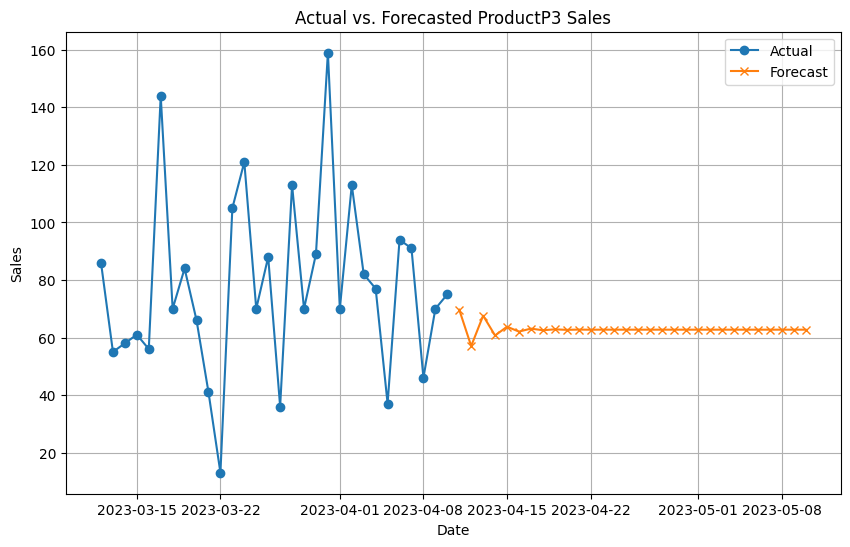

In [489]:
import matplotlib.pyplot as plt

# Plot actual vs. forecasted values
plt.figure(figsize=(10, 6))
plt.plot(test_data.index, test_data['ProductP4'], label='Actual', marker='o')
plt.plot(forecast_dates, forecast_test[:, 0], label='Forecast', marker='x')
plt.title('Actual vs. Forecasted ProductP3 Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid()
plt.show()

In [ ]:
param_grid = {
    'coint_rank': [1, 2, 3, 4,5,6,7,8,9,10],  # Test for 1 or 2 cointegrating relationships
    'k_ar_diff': [1, 2, 3, 4, 5],  # Test for 1, 2, or 3 lags
    'deterministic': ['nc', 'co', 'lo']  # No constant, constant in cointegration, linear trend in cointegration
}

In [490]:
# Step 3: Perform Grid Search
best_aic = float('inf')
best_params = None

for params in itertools.product(*param_grid.values()):
    coint_rank, k_ar_diff, deterministic = params
    try:
        # Fit VECM model
        model = VECM(df_vecm[['ProductP4', 'ProductP3', 'temperature', 'price']],
                     coint_rank=coint_rank,
                     k_ar_diff=k_ar_diff,
                     deterministic=deterministic)
        results = model.fit()

        # Compute AIC manually
        llf = results.llf  # Log-likelihood

        # Calculate the number of parameters
        n_vars = len(data.columns)  # Number of variables
        n_lags = k_ar_diff  # Number of lags
        n_coint = coint_rank  # Cointegration rank
        n_params = n_vars * n_lags + n_coint * n_vars  # Total number of parameters

        aic = -2 * llf + 2 * n_params

        print(f"Params: {params}, AIC: {aic}")

        # Update best parameters if current model is better
        if aic < best_aic:
            best_aic = aic
            best_params = params
    except Exception as e:
        print(f"Error with params {params}: {e}")

print(f"Best Parameters: {best_params}, Best AIC: {best_aic}")

C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No f

Params: (1, 1, 'nc'), AIC: 2799.486738342106
Params: (1, 1, 'co'), AIC: 2787.9008323309044
Params: (1, 1, 'lo'), AIC: 2784.3771744152136
Params: (1, 2, 'nc'), AIC: 2743.198784592374
Params: (1, 2, 'co'), AIC: 2723.381748517535
Params: (1, 2, 'lo'), AIC: 2711.9622779506117
Params: (1, 3, 'nc'), AIC: 2656.326965744061
Params: (1, 3, 'co'), AIC: 2640.382020619886
Params: (1, 3, 'lo'), AIC: 2637.585373152523
Params: (1, 4, 'nc'), AIC: 2605.5192903468915
Params: (1, 4, 'co'), AIC: 2590.937484676344
Params: (1, 4, 'lo'), AIC: 2578.51620663256
Params: (1, 5, 'nc'), AIC: 2529.625460363717
Params: (1, 5, 'co'), AIC: 2518.5794375163796
Params: (1, 5, 'lo'), AIC: 2511.8453799181716
Params: (2, 1, 'nc'), AIC: 2774.0264230487774
Params: (2, 1, 'co'), AIC: 2753.7200557132956
Params: (2, 1, 'lo'), AIC: 2745.7874392551535
Params: (2, 2, 'nc'), AIC: 2724.956416758929
Params: (2, 2, 'co'), AIC: 2689.9048836731063
Params: (2, 2, 'lo'), AIC: 2676.435820893383
Params: (2, 3, 'nc'), AIC: 2646.789948737619
P

C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No f

Params: (3, 4, 'nc'), AIC: 2596.5902143226067
Params: (3, 4, 'co'), AIC: 2565.5094707427534
Params: (3, 4, 'lo'), AIC: 2555.8611596878563
Params: (3, 5, 'nc'), AIC: 2525.88624177005
Params: (3, 5, 'co'), AIC: 2503.4771609926356
Params: (3, 5, 'lo'), AIC: 2492.092591790827
Params: (4, 1, 'nc'), AIC: 2784.9977935644047
Params: (4, 1, 'co'), AIC: 2736.5827530375386
Params: (4, 1, 'lo'), AIC: 2734.16205122434
Params: (4, 2, 'nc'), AIC: 2737.0178369639516
Params: (4, 2, 'co'), AIC: 2682.415460735111
Params: (4, 2, 'lo'), AIC: 2667.073691587548
Params: (4, 3, 'nc'), AIC: 2659.9803359132816
Params: (4, 3, 'co'), AIC: 2621.2417185384734
Params: (4, 3, 'lo'), AIC: 2615.766474203758
Params: (4, 4, 'nc'), AIC: 2604.4663703664337
Params: (4, 4, 'co'), AIC: 2572.9175541252675
Params: (4, 4, 'lo'), AIC: 2563.554004234651
Params: (4, 5, 'nc'), AIC: 2533.884406700322
Params: (4, 5, 'co'), AIC: 2510.9815606186085
Params: (4, 5, 'lo'), AIC: 2500.068628566878
Params: (5, 1, 'nc'), AIC: 2792.9977935644047

C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No f

Params: (8, 1, 'co'), AIC: 2768.5827530375386
Params: (8, 1, 'lo'), AIC: 2766.16205122434
Params: (8, 2, 'nc'), AIC: 2769.0178369639516
Params: (8, 2, 'co'), AIC: 2714.415460735111
Params: (8, 2, 'lo'), AIC: 2699.073691587548
Params: (8, 3, 'nc'), AIC: 2691.9803359132816
Params: (8, 3, 'co'), AIC: 2653.2417185384734
Params: (8, 3, 'lo'), AIC: 2647.766474203758
Params: (8, 4, 'nc'), AIC: 2636.4663703664337
Params: (8, 4, 'co'), AIC: 2604.9175541252675
Params: (8, 4, 'lo'), AIC: 2595.554004234651
Params: (8, 5, 'nc'), AIC: 2565.884406700322
Params: (8, 5, 'co'), AIC: 2542.9815606186085
Params: (8, 5, 'lo'), AIC: 2532.068628566878
Params: (9, 1, 'nc'), AIC: 2824.9977935644047
Params: (9, 1, 'co'), AIC: 2776.5827530375386
Params: (9, 1, 'lo'), AIC: 2774.16205122434
Params: (9, 2, 'nc'), AIC: 2777.0178369639516
Params: (9, 2, 'co'), AIC: 2722.415460735111
Params: (9, 2, 'lo'), AIC: 2707.073691587548
Params: (9, 3, 'nc'), AIC: 2699.9803359132816
Params: (9, 3, 'co'), AIC: 2661.2417185384734


C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No f

Params: (10, 2, 'lo'), AIC: 2715.073691587548
Params: (10, 3, 'nc'), AIC: 2707.9803359132816
Params: (10, 3, 'co'), AIC: 2669.2417185384734
Params: (10, 3, 'lo'), AIC: 2663.766474203758
Params: (10, 4, 'nc'), AIC: 2652.4663703664337
Params: (10, 4, 'co'), AIC: 2620.9175541252675
Params: (10, 4, 'lo'), AIC: 2611.554004234651
Params: (10, 5, 'nc'), AIC: 2581.884406700322
Params: (10, 5, 'co'), AIC: 2558.9815606186085
Params: (10, 5, 'lo'), AIC: 2548.068628566878
Best Parameters: (3, 5, 'lo'), Best AIC: 2492.092591790827


C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No f

In [491]:
# Step 4: Fit the Best Model
best_coint_rank, best_k_ar_diff, best_deterministic = best_params
best_model = VECM(df_vecm[['ProductP4', 'ProductP3', 'temperature', 'price']],
                  coint_rank=best_coint_rank,
                  k_ar_diff=best_k_ar_diff,
                  deterministic=best_deterministic)
best_results = best_model.fit()

C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [492]:
# Display summary of the best model
print(best_results.summary())

Det. terms outside the coint. relation & lagged endog. parameters for equation ProductP4
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
lin_trend         -1.7299      0.680     -2.543      0.011      -3.063      -0.397
L1.ProductP4      -0.1540      0.222     -0.693      0.488      -0.590       0.282
L1.ProductP3      -0.1734      0.087     -2.004      0.045      -0.343      -0.004
L1.temperature    -1.2721      1.577     -0.807      0.420      -4.362       1.818
L1.price          12.4469     13.068      0.952      0.341     -13.166      38.060
L2.ProductP4      -0.3071      0.197     -1.561      0.119      -0.693       0.078
L2.ProductP3      -0.1496      0.074     -2.023      0.043      -0.295      -0.005
L2.temperature    -3.3960      1.600     -2.122      0.034      -6.532      -0.260
L2.price           9.2292     11.675      0.790      0.429     -13.654      32.11

In [493]:
# Step 5: Validate the Model
train_data = df_vecm.iloc[:-30]  # Use all but the last 30 days for training
test_data = df_vecm.iloc[-30:]   # Last 30 days for testing

In [494]:
# Fit the best model on the training data
best_model_train = VECM(train_data[['ProductP4', 'ProductP3', 'temperature', 'price']],
                        coint_rank=best_coint_rank,
                        k_ar_diff=best_k_ar_diff,
                        deterministic=best_deterministic)
best_results_train = best_model_train.fit()

C:\Users\Administrator\.conda\envs\py3_9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [495]:
# Forecast on the test data
forecast_test = best_results_train.predict(steps=30)

In [496]:
# Calculate MAE
mae = mean_absolute_error(test_data['ProductP4'], forecast_test[:, 0])
print(f'Mean Absolute Error (MAE): {mae}')

Mean Absolute Error (MAE): 27.611580798595842


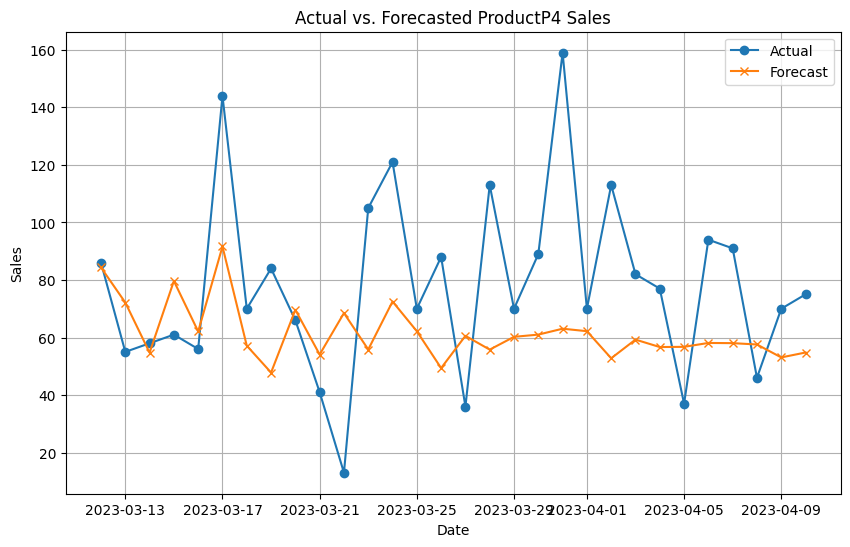

In [497]:
# Step 6: Visualize Results
plt.figure(figsize=(10, 6))
plt.plot(test_data.index, test_data['ProductP4'], label='Actual', marker='o')
plt.plot(test_data.index, forecast_test[:, 0], label='Forecast', marker='x')
plt.title('Actual vs. Forecasted ProductP4 Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid()
plt.show()

### Product 5

In [301]:
# Rename columns for FBProphet
df_prophet = df.rename(columns={"t": "ds", "ProductP5": "y"})

# Convert 'ds' into a proper datetime format (assuming 't' represents sequential days)
df_prophet["ds"] = pd.date_range(start="2023-01-01", periods=len(df_prophet), freq="D")

# Keep only necessary columns
df_prophet = df_prophet[["ds", "y"]]

In [302]:
# Initialize Prophet model
model = Prophet()
# model.add_regressor("temp")  # Add temperature as an external regressor

# Fit the model
model.fit(df_prophet)

# Create future dataframe (next 30 days)
future = model.make_future_dataframe(periods=30)
# future["temp"] = df_prophet["temp"].mean()  # Assuming average temperature for future predictions

# Forecast
forecast = model.predict(future)

20:16:49 - cmdstanpy - INFO - Chain [1] start processing
20:16:49 - cmdstanpy - INFO - Chain [1] done processing


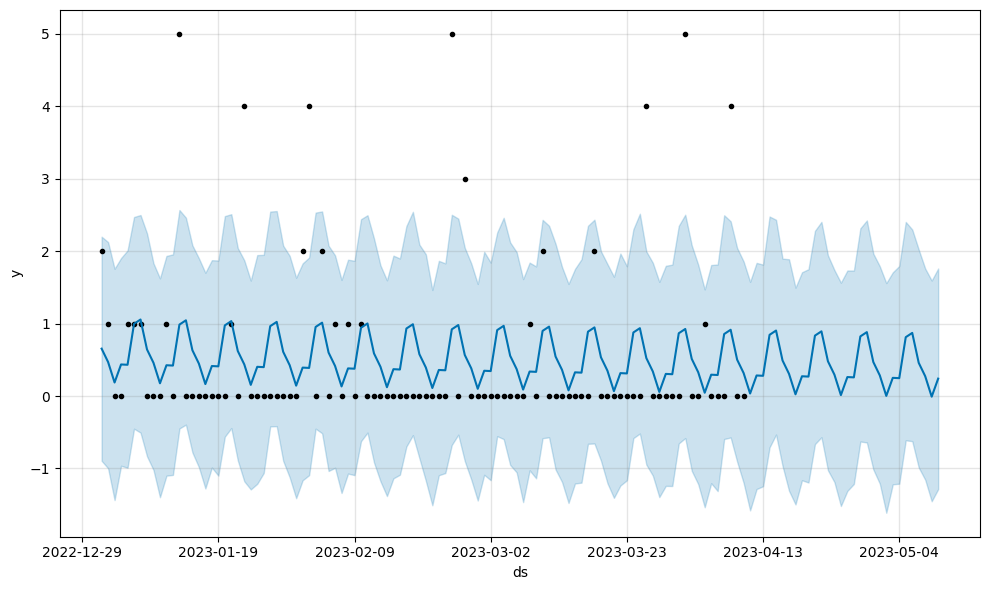

In [303]:
# Plot forecast
fig = model.plot(forecast)
plt.show()

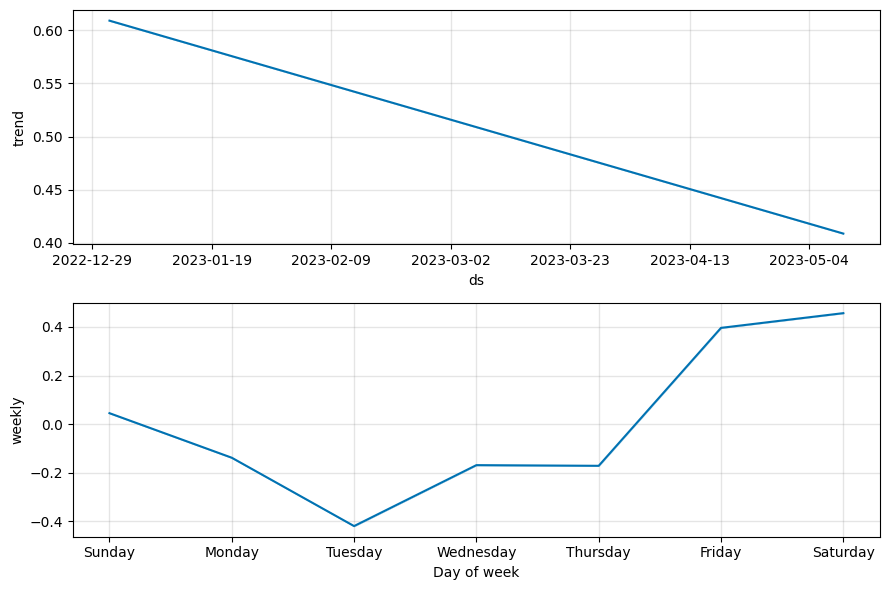

In [304]:
# Plot forecast components (trend, seasonality, effect of temp)
fig2 = model.plot_components(forecast)
plt.show()

In [305]:
from prophet import Prophet
from sklearn.model_selection import ParameterGrid
import numpy as np

# Define hyperparameter grid
param_grid = {
    "changepoint_prior_scale": [0.5, 0.6, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0],
    "seasonality_prior_scale": [10.0, 20.0, 25.0, 30.0, 35.0, 40.0],
    "seasonality_mode": ["additive", "multiplicative"]
}

# Create all combinations of parameters
grid = list(ParameterGrid(param_grid))

# Split dataset for cross-validation
split_point = int(len(df_prophet) * 0.8)  # 80% train, 20% test
train_df = df_prophet[:split_point]
test_df = df_prophet[split_point:]

best_model = None
best_mse = float("inf")
best_params = None

for params in grid:
    # Initialize and fit model
    model = Prophet(
        changepoint_prior_scale=params["changepoint_prior_scale"],
        seasonality_prior_scale=params["seasonality_prior_scale"],
        seasonality_mode=params["seasonality_mode"]
    )
    # model.add_regressor("temp")
    model.fit(train_df)
    
    # Make future dataframe
    future = model.make_future_dataframe(periods=len(test_df))
    # future["temp"] = test_df["temp"].values  # Use actual future temperature values

    # Predict
    forecast = model.predict(future)
    
    # Calculate error (Mean Squared Error)
    mse = np.mean((forecast["yhat"].iloc[-len(test_df):].values - test_df["y"].values) ** 2)
    
    # Save the best model
    if mse < best_mse:
        best_mse = mse
        best_model = model
        best_params = params

print("Best Parameters:", best_params)
print("Best MSE:", best_mse)

20:17:15 - cmdstanpy - INFO - Chain [1] start processing
20:17:15 - cmdstanpy - INFO - Chain [1] done processing
20:17:15 - cmdstanpy - INFO - Chain [1] start processing
20:17:16 - cmdstanpy - INFO - Chain [1] done processing
20:17:16 - cmdstanpy - INFO - Chain [1] start processing
20:17:16 - cmdstanpy - INFO - Chain [1] done processing
20:17:17 - cmdstanpy - INFO - Chain [1] start processing
20:17:17 - cmdstanpy - INFO - Chain [1] done processing
20:17:17 - cmdstanpy - INFO - Chain [1] start processing
20:17:17 - cmdstanpy - INFO - Chain [1] done processing
20:17:17 - cmdstanpy - INFO - Chain [1] start processing
20:17:18 - cmdstanpy - INFO - Chain [1] done processing
20:17:18 - cmdstanpy - INFO - Chain [1] start processing
20:17:18 - cmdstanpy - INFO - Chain [1] done processing
20:17:19 - cmdstanpy - INFO - Chain [1] start processing
20:17:19 - cmdstanpy - INFO - Chain [1] done processing
20:17:20 - cmdstanpy - INFO - Chain [1] start processing
20:17:20 - cmdstanpy - INFO - Chain [1]

Best Parameters: {'changepoint_prior_scale': 0.6, 'seasonality_mode': 'multiplicative', 'seasonality_prior_scale': 25.0}
Best MSE: 2.6833879727688155


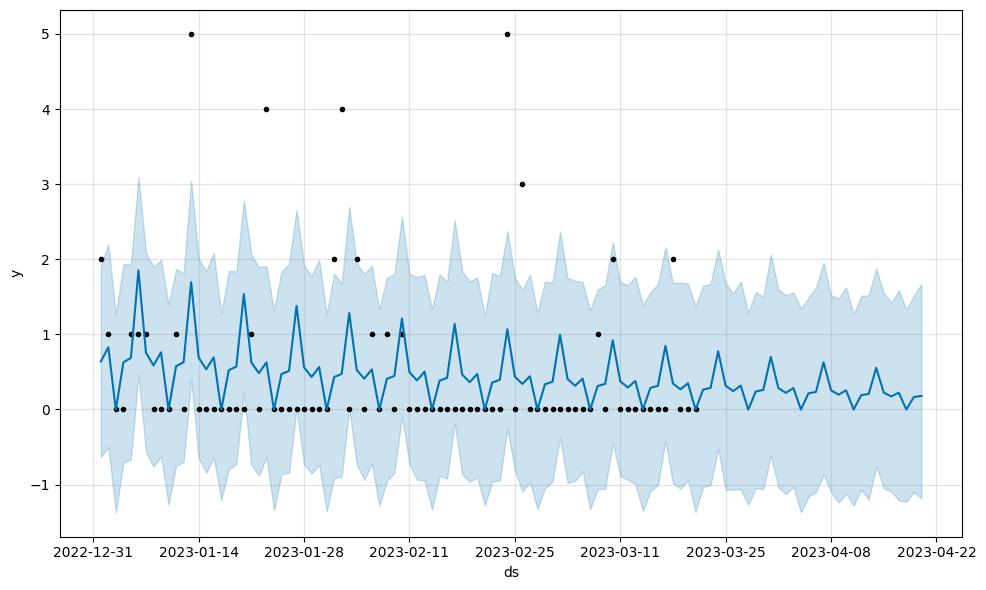

In [306]:
# Predict using the best model
future = best_model.make_future_dataframe(periods=30)
# future["temp"] = df_prophet["temp"].mean()  # Assuming avg temperature

forecast = best_model.predict(future)

# Plot the forecast
best_model.plot(forecast)
plt.show()

In [307]:
# Adjust parameters for small dataset
df_cv = cross_validation(best_model, 
                         horizon="10 days",   # Reduce forecast window
                         period="2 days",    # Reduce step size
                         initial="60 days")  # Ensure training window fits data

# Evaluate performance
df_perf = performance_metrics(df_cv)
df_perf

  0%|          | 0/5 [00:00<?, ?it/s]

20:19:06 - cmdstanpy - INFO - Chain [1] start processing
20:19:06 - cmdstanpy - INFO - Chain [1] done processing
20:19:06 - cmdstanpy - INFO - Chain [1] start processing
20:19:07 - cmdstanpy - INFO - Chain [1] done processing
20:19:07 - cmdstanpy - INFO - Chain [1] start processing
20:19:07 - cmdstanpy - INFO - Chain [1] done processing
20:19:08 - cmdstanpy - INFO - Chain [1] start processing
20:19:08 - cmdstanpy - INFO - Chain [1] done processing
20:19:08 - cmdstanpy - INFO - Chain [1] start processing
20:19:09 - cmdstanpy - INFO - Chain [1] done processing


,horizon,mse,rmse,mae,mdape,smape,coverage
0,1 days,0.439683,0.663086,0.634605,inf,1.543581,1.0
1,2 days,0.173225,0.416204,0.366737,inf,2.000000,1.0
2,3 days,0.378087,0.614888,0.520866,inf,1.535105,1.0
3,4 days,0.139922,0.374062,0.334939,inf,2.000000,1.0
4,5 days,0.302747,0.550224,0.465796,inf,1.500217,1.0
5,6 days,0.609262,0.780552,0.631677,inf,2.000000,0.8
6,7 days,0.655505,0.809633,0.606455,inf,1.545543,0.8
7,8 days,0.360331,0.600276,0.556289,inf,2.000000,1.0
8,9 days,0.710273,0.842777,0.634285,inf,1.885833,0.8
9,10 days,0.296051,0.544106,0.443484,inf,2.000000,1.0
